# Somatic Hyper Mutation Analysis

In [1]:
#utils I made to look at this data
import switchy.util as ut
import pandas as pd
import numpy as np
import scipy
import sys
import os
import time
import random
import copy
import math
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import scanpy as sc
import seaborn as sns
import autoreload
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 300
   }

mpl.rcParams.update(params)

sns.set_style("ticks")

savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": True}
mpl.rc('savefig', dpi=300)
output_dir = "outs"
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

data_dir = "../data/"
#import auto reload
%load_ext autoreload
%autoreload 2

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/anndata/_core/anndata.py:21: FutureWarning: pandas.core.index is deprecated and will be removed in a future version.  The public classes are available in the top-level namespace.
  from pandas.core.index import RangeIndex


In [2]:
adata = sc.read_h5ad(data_dir + 'Combined_PC' + '.h5ad')
changeodb = pd.read_csv('../../../ImmTrinity/ShazamTrinity.tab', index_col = None, sep = '\t')

In [3]:
# Getting data
#adata = sc.read_h5ad(data_dir + 'Combined' + '.h5ad')
# Cell names have batch number next to them which is not needed
adata.obs.index = adata.obs.index.str[:-2]
adata = ut.preprocessScanpy(adata, num_counted_reads=40000, num_genes=500, min_cells=10, n_neighbors= 6, num_highly_variable=600)

making var_names unique
filtering cells with less than 40000 counted reads
filtering cells with less than 500 genes detected
filtering genes detected in less than 10
normalizing by total counts per cell
log transforming data
removed ERCC sequences from genes to cluster on
removing variable immune receptor genes which may drive clustering
calculating highly variable genes


Trying to set attribute `.var` of view, copying.


calculating PCA
creating neighbors graph with 6
umapping and tsne-ing


In [4]:
# MUNGE THE sequence id to get a Cell column and a Donor Column
changeodb = pd.read_csv('../../../ImmTrinity/ShazamTrinity.tab', index_col = None, sep = '\t')

_x = changeodb.SEQUENCE_ID.str.split('_')[0][1:-7]

cell_list = []
for SeqID in changeodb.SEQUENCE_ID:
    _x = SeqID.split('_')[1:-7]
    cell_list.append('_'.join(_x))

changeodb['CELL'] = cell_list
changeodb['Donor'] = changeodb.SEQUENCE_ID.str.split(' ', expand = True)[1]

In [5]:
# Interesting the Clone Calling is much larger with the Light Chain
changeodb.CLONE.value_counts()

598     118
1393     97
1455     85
1587     83
280      80
       ... 
1026      1
1030      1
1034      1
1038      1
2049      1
Name: CLONE, Length: 2272, dtype: int64

In [6]:
df_contig_aggr = changeodb.groupby(["Donor", "CELL", "LOCUS"]).size().unstack(fill_value=0)


In [7]:
df_contig_aggr.head()
print(np.sum(df_contig_aggr, axis=0))

LOCUS
IGH    2207
IGK    1603
IGL    1221
dtype: int64


2 4


Text(1.0, 1.0, '1734')

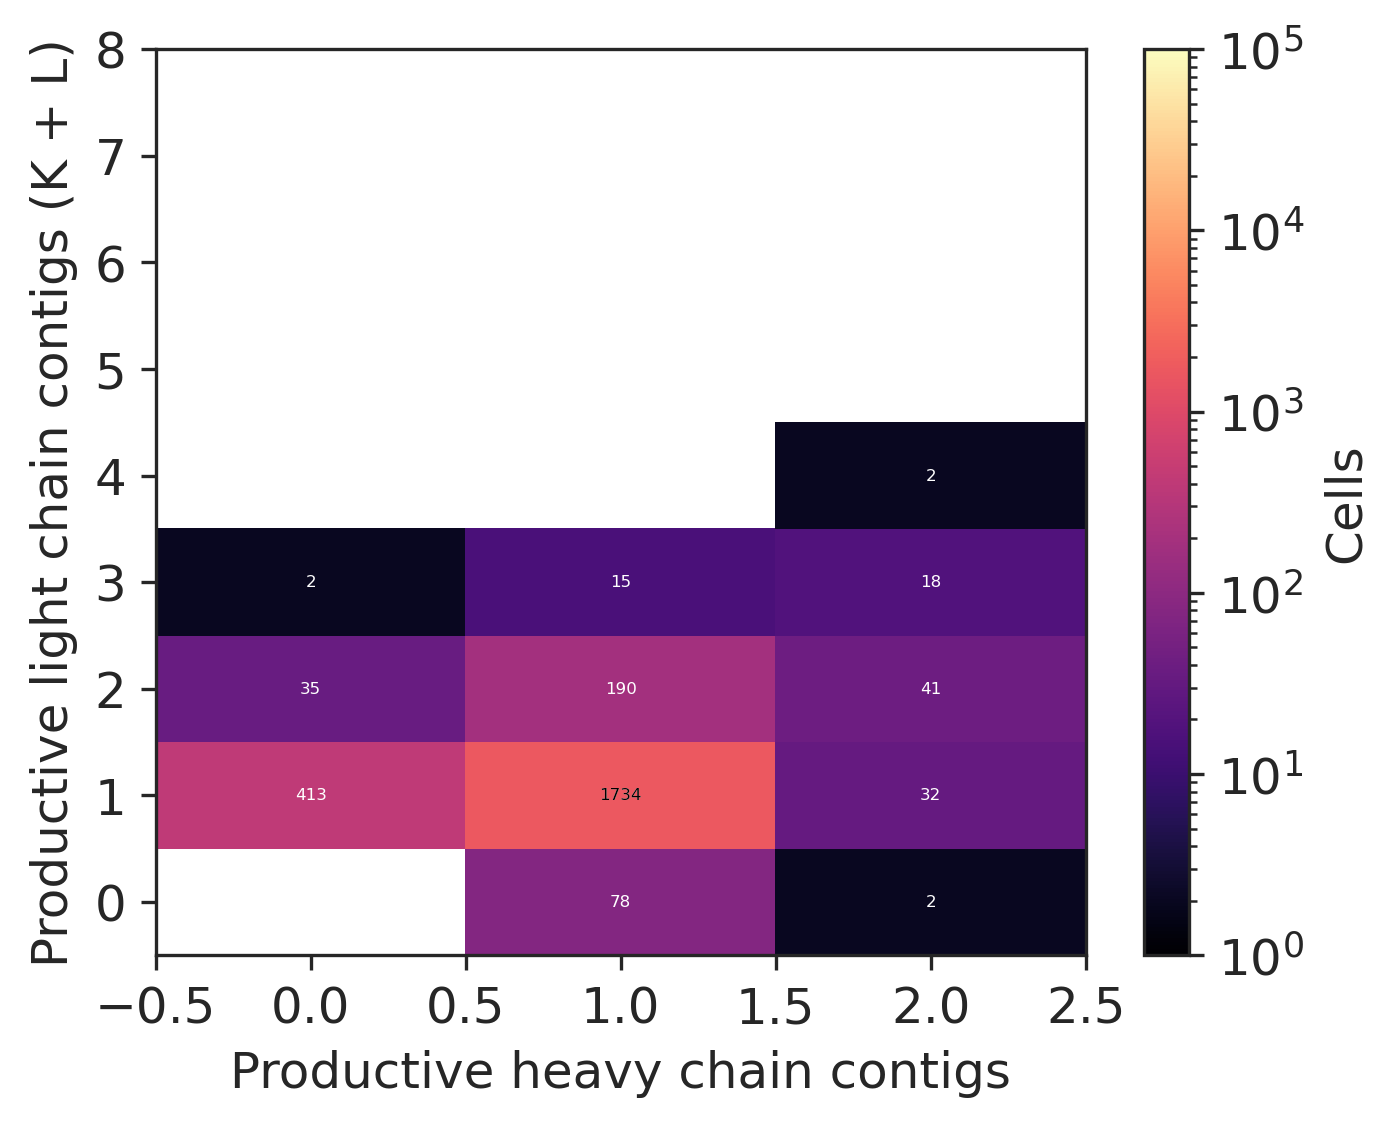

In [8]:
# Examine number of high-quality contigs assembled per cell (joint distribution of IGH, IGK/L)
# full range

x = df_contig_aggr["IGH"]
y = df_contig_aggr["IGL"] + df_contig_aggr["IGK"]

print(max(x), max(y))
xbins = np.array(range(0,max(x)+2))-0.5
ybins = np.array(range(0,max(y)+2))-0.5

fig, ax = plt.subplots(1, 1, figsize=(5,4))

counts, xedges, yedges, im = ax.hist2d(x, y, bins=(xbins, ybins),
                                       cmap="magma",
                                       norm=mpl.colors.LogNorm(1, 1e5))

ax.set_xlabel("Productive heavy chain contigs")
ax.set_ylabel("Productive light chain contigs (K + L)")
plt.colorbar(im, ax=ax, label="Cells")

ax.set_ylim(top=8)

# show counts
dx = xedges[2]-xedges[1]
dy = yedges[2]-yedges[1]
for i in range(xedges.size-1):
    for j in range(yedges.size-1):
        xb = xedges[i] + 0.5*dx
        yb = yedges[j] + 0.5*dy 
        ax.text(xb, yb, str(int(counts[i,j])), fontsize=4, ha="center", va="center", color="w")

# show count of 1H+1L in black
xb = xedges[1] + 0.5*dx
yb = yedges[1] + 0.5*dy 
ax.text(xb, yb, str(int(counts[1,1])), fontsize=4, ha="center", va="center", color="k")

In [9]:
df_contig_aggr_filtered = df_contig_aggr

In [10]:

# Filter for cells having exactly 1H+1L
df_contig_aggr_filtered = df_contig_aggr
df = df_contig_aggr_filtered.loc[(df_contig_aggr_filtered["IGH"] == 1) &
                                 (((df_contig_aggr_filtered["IGL"] == 1) & (df_contig_aggr_filtered["IGK"] == 0)) |
                                  ((df_contig_aggr_filtered["IGL"] == 0) & (df_contig_aggr_filtered["IGK"] == 1)))]
df.head()
# Filter orginal Changeodb to include only singlets
df_all_contig_annotations_valid = changeodb.set_index(["Donor", "CELL"]).loc[df.index]
print(df_all_contig_annotations_valid.shape)

# Filter contigs for only IGH, IGL, or IGK
df_all_contig_annotations_valid = df_all_contig_annotations_valid.loc[df_all_contig_annotations_valid["LOCUS"].isin(["IGH", "IGL", "IGK"])]
print (df_all_contig_annotations_valid.shape)
df_all_contig_annotations_valid.head()

# Filter contigs for only productive
df_all_contig_annotations_valid = df_all_contig_annotations_valid.loc[df_all_contig_annotations_valid["FUNCTIONAL"] == True]
print (df_all_contig_annotations_valid.shape)
df_all_contig_annotations_valid.head()

(3468, 60)
(3468, 60)
(3468, 60)


SEQUENCE_ID                                     SEQUENCE_INPUT  FUNCTIONAL  IN_FRAME   STOP  MUTATED_INVARIANT  INDELS LOCUS                    V_CALL                 D_CALL             J_CALL                                       SEQUENCE_VDJ                                      SEQUENCE_IMGT  V_SEQ_START  V_SEQ_LENGTH  V_GERM_START_VDJ  V_GERM_LENGTH_VDJ  V_GERM_START_IMGT  V_GERM_LENGTH_IMGT  NP1_LENGTH  D_SEQ_START  D_SEQ_LENGTH  D_GERM_START  D_GERM_LENGTH  NP2_LENGTH  J_SEQ_START  J_SEQ_LENGTH  J_GERM_START  J_GERM_LENGTH                                           JUNCTION  JUNCTION_LENGTH                                      GERMLINE_IMGT  V_SCORE  V_IDENTITY       V_EVALUE                                            V_CIGAR  D_SCORE  D_IDENTITY      D_EVALUE         D_CIGAR  J_SCORE  J_IDENTITY      J_EVALUE     J_CIGAR                                          FWR1_IMGT  \
Donor   CELL                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             
Donor_0 IL6811-701-503  bracer_IL6811-701-503_TRINITY_DN2_c0_g1_i1_H D...  GTGTCCAGTGTGAGGTGCAGCTGTTGGAGTCTGGGGGAGGCTTGGT...        True      True  False                NaN   False   IGH  IGHV3-23*01,IGHV3-23D*01            IGHD3-10*01           IGHJ3*01  GAGGTGCAGCTGTTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGGG...  GAGGTGCAGCTGTTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...           12           296                 1                296                  1                 320           8        316.0          18.0          11.0           18.0         1.0          335            47             4             47  TGTGCGAAAGATGACTTAGGGTTCGGGGACCTATTATTTGCTTTTG...               54  GAGGTGCAGCTGTTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...    416.0     0.94932  5.110000e-118  11S59=1X29=1X63=1X5=1X2=2X6=2X1=1X8=1X47=1X2=1...     23.8     0.88889  2.900000e-02  315S10N10=2X6=     91.1         1.0  2.960000e-22   334S3N47=  GAGGTGCAGCTGTTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...   
        IL6811-701-503  bracer_IL6811-701-503_TRINITY_DN0_c0_g1_i1_L D...  GGTCCTGGGCCCAGTCTGCCCTGACTCAGCCTGCCTCCGTGTCTGG...        True      True  False                NaN   False   IGL               IGLV2-14*01                    NaN           IGLJ1*01  CAGTCTGCCCTGACTCAGCCTGCCTCCGTGTCTGGGTCTCCTGGAC...  CAGTCTGCCCTGACTCAGCCTGCCTCC...GTGTCTGGGTCTCCTG...           12           293                 1                293                  1                 335           6          NaN           NaN           NaN            NaN         NaN          311            35             4             35            TGCAGCTCATTTACAATTAGGAGCACCCCTTGTGTCTTC               39  CAGTCTGCCCTGACTCAGCCTGCCTCC...GTGTCTGGGTCTCCTG...    430.0     0.96928  2.960000e-122             11S94=1X2=2X20=1X125=1X31=1X5=2X2=1X5=      NaN         NaN           NaN             NaN     68.0         1.0  2.520000e-15   310S3N35=  CAGTCTGCCCTGACTCAGCCTGCCTCC...GTGTCTGGGTCTCCTG...   
        IL6811-701-505  bracer_IL6811-701-505_TRINITY_DN0_c0_g1_i1_H D...  TGTCCAGTGTGAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTC...        True      True  False                NaN   False   IGH               IGHV3-73*01  IGHD2-2*01,IGHD2-2*03           

In [11]:
df_all_contig_annotations_valid['MU_FREQ'] = df_all_contig_annotations_valid['MU_FREQ_SEQ_R'] + df_all_contig_annotations_valid['MU_FREQ_SEQ_S']
df_all_contig_annotations_valid['MU_COUNT'] = df_all_contig_annotations_valid['MU_COUNT_SEQ_R'] + df_all_contig_annotations_valid['MU_COUNT_SEQ_S']

In [12]:
# Filter contigs for only IGH (for mapping into repertoire)
df_all_contig_annotations_valid_IGH = df_all_contig_annotations_valid.loc[df_all_contig_annotations_valid["LOCUS"].isin(["IGH"])]
print (df_all_contig_annotations_valid_IGH.shape)
df_all_contig_annotations_valid_IGH.head()

(1734, 62)


SEQUENCE_ID                                     SEQUENCE_INPUT  FUNCTIONAL  IN_FRAME   STOP  MUTATED_INVARIANT  INDELS LOCUS                    V_CALL                               D_CALL             J_CALL                                       SEQUENCE_VDJ                                      SEQUENCE_IMGT  V_SEQ_START  V_SEQ_LENGTH  V_GERM_START_VDJ  V_GERM_LENGTH_VDJ  V_GERM_START_IMGT  V_GERM_LENGTH_IMGT  NP1_LENGTH  D_SEQ_START  D_SEQ_LENGTH  D_GERM_START  D_GERM_LENGTH  NP2_LENGTH  J_SEQ_START  J_SEQ_LENGTH  J_GERM_START  J_GERM_LENGTH                                           JUNCTION  JUNCTION_LENGTH                                      GERMLINE_IMGT  V_SCORE  V_IDENTITY       V_EVALUE                                            V_CIGAR  D_SCORE  D_IDENTITY      D_EVALUE         D_CIGAR  J_SCORE  J_IDENTITY      J_EVALUE              J_CIGAR                                          FWR1_IMGT  \
Donor   CELL                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
Donor_0 IL6811-701-503  bracer_IL6811-701-503_TRINITY_DN2_c0_g1_i1_H D...  GTGTCCAGTGTGAGGTGCAGCTGTTGGAGTCTGGGGGAGGCTTGGT...        True      True  False                NaN   False   IGH  IGHV3-23*01,IGHV3-23D*01                          IGHD3-10*01           IGHJ3*01  GAGGTGCAGCTGTTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGGG...  GAGGTGCAGCTGTTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...           12           296                 1                296                  1                 320           8        316.0          18.0          11.0           18.0         1.0          335            47             4             47  TGTGCGAAAGATGACTTAGGGTTCGGGGACCTATTATTTGCTTTTG...               54  GAGGTGCAGCTGTTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...    416.0     0.94932  5.110000e-118  11S59=1X29=1X63=1X5=1X2=2X6=2X1=1X8=1X47=1X2=1...     23.8     0.88889  2.900000e-02  315S10N10=2X6=     91.1     1.00000  2.960000e-22            334S3N47=  GAGGTGCAGCTGTTGGAGTCTGGGGGA...GGCTTGGTACAGCCTG...   
        IL6811-701-505  bracer_IL6811-701-505_TRINITY_DN0_c0_g1_i1_H D...  TGTCCAGTGTGAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTC...        True      True  False                NaN   False   IGH               IGHV3-73*01                IGHD2-2*01,IGHD2-2*03           IGHJ4*02  GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...  GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTCCAGCCTG...           11           301                 1                301                  1                 319           4        316.0          23.0           7.0           23.0        10.0          349            41             8             41  TGTACTAGACTGTCTTGTAGTAGTACCAGCTGCTATGGGAGGATTG...               57  GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTCCAGCCTG...    470.0     1.00000  2.010000e-134                                            10S301=     44.9     1.00000  1.290000e-08       315S6N23=     79.5     1.00000  9.000000e-19            348S7N41=  GAGGTGCAGCTGGTGGAGTCTGGGGGA...GGCTTGGTCCAGCCTG...   
        IL6811-701-506  bracer_IL6811-701-506_TRINITY_DN1_c0_g2_i1_H D...  GTCCAGTGTGAGGTGCAGCTGTTGGAGTCTGGGGGAGGCTTGGTAC...        True      True  False 

In [90]:
_x = df_all_contig_annotations_valid_IGH[df_all_contig_annotations_valid_IGH['Donor'] == 'SS2_TS']

In [94]:
_x.CLONE.value_counts()

555     4
1691    3
1122    3
475     3
1422    2
1911    2
1315    2
1595    2
1115    2
1228    2
1718    2
2027    1
589     1
141     1
2188    1
2187    1
146     1
137     1
150     1
136     1
646     1
644     1
638     1
2169    1
632     1
2166    1
1652    1
1135    1
147     1
511     1
1175    1
1176    1
720     1
717     1
1225    1
2246    1
1803    1
705     1
1059    1
703     1
1726    1
1210    1
1721    1
1719    1
1711    1
2125    1
1688    1
1704    1
1190    1
1186    1
1697    1
1180    1
1129    1
1643    1
1121    1
1698    1
1560    1
1069    1
1068    1
1063    1
548     1
1070    1
1057    1
1862    1
1243    1
539     1
1047    1
1071    1
481     1
533     1
1039    1
525     1
1546    1
1545    1
2047    1
517     1
1539    1
1582    1
1075    1
1124    1
584     1
1747    1
1365    1
2133    1
1620    1
1615    1
1102    1
1101    1
1100    1
1099    1
1607    1
1590    1
1605    1
1604    1
2114    1
1600    1
1087    1
2106    1
1593    1
1592    1


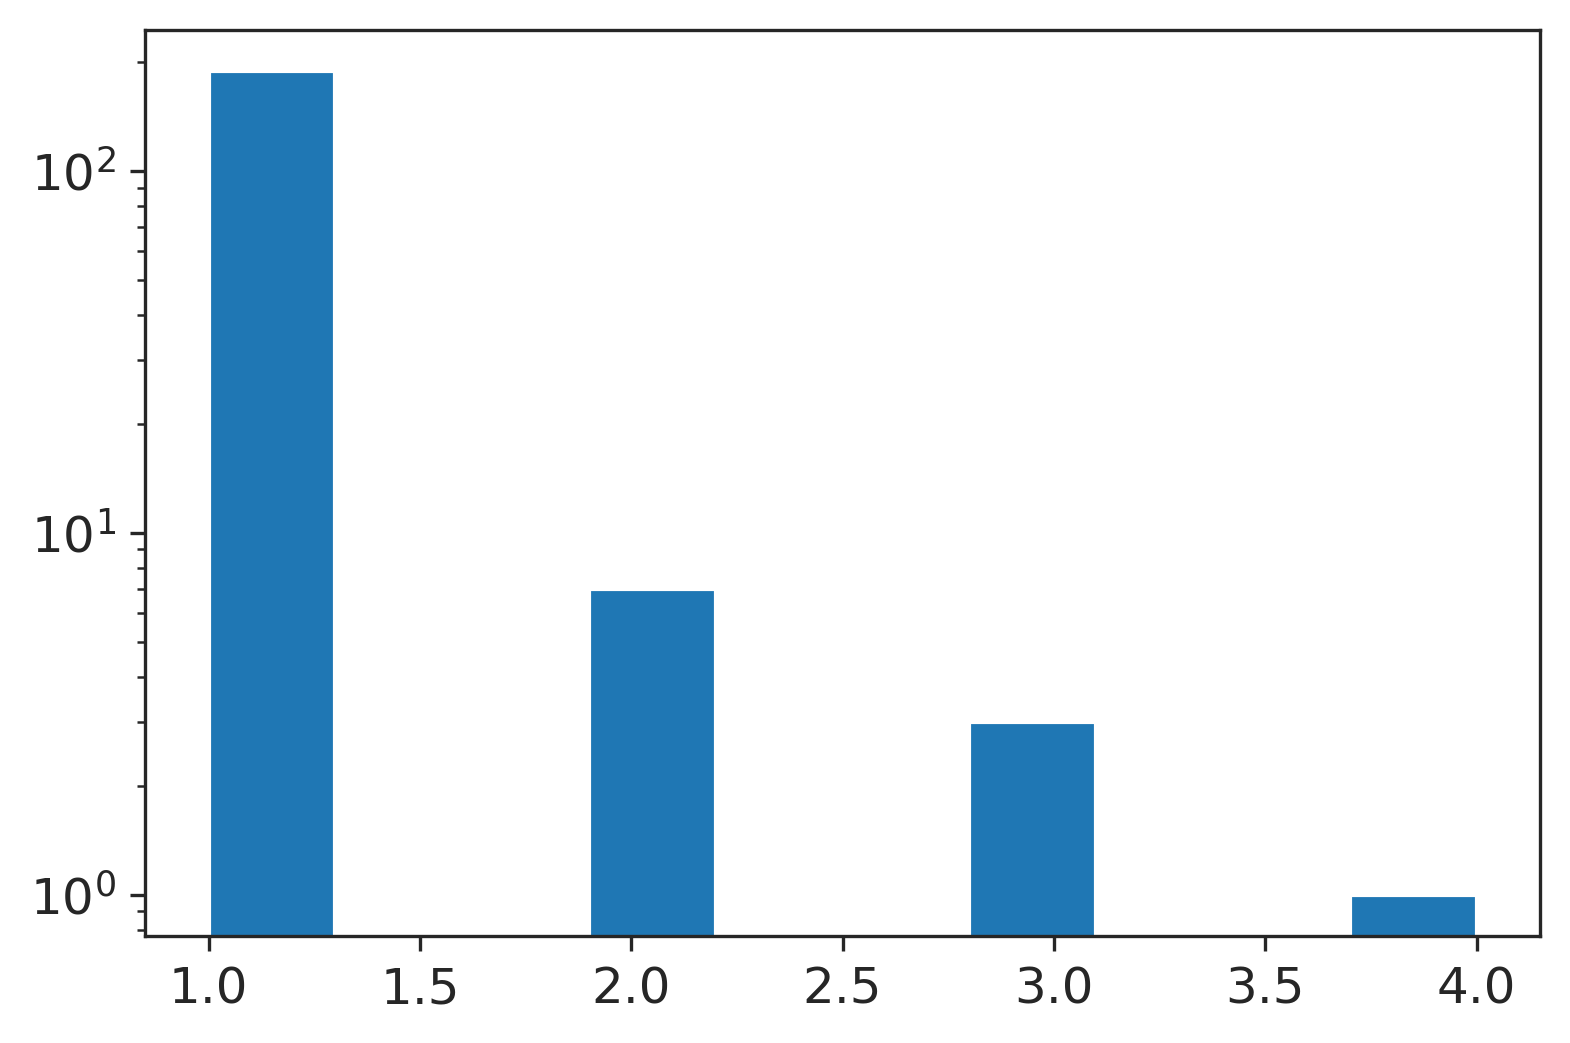

In [97]:
plt.hist(_x.CLONE.value_counts())
plt.yscale('log')

In [13]:
changeodb_H = df_all_contig_annotations_valid_IGH

changeodb_H.reset_index(inplace=True)

changeo = df_all_contig_annotations_valid.reset_index()
changeo_KL = changeo[changeo.LOCUS != 'IGH']

In [14]:
mergedchangeos = pd.concat([changeodb_H, changeo_KL])

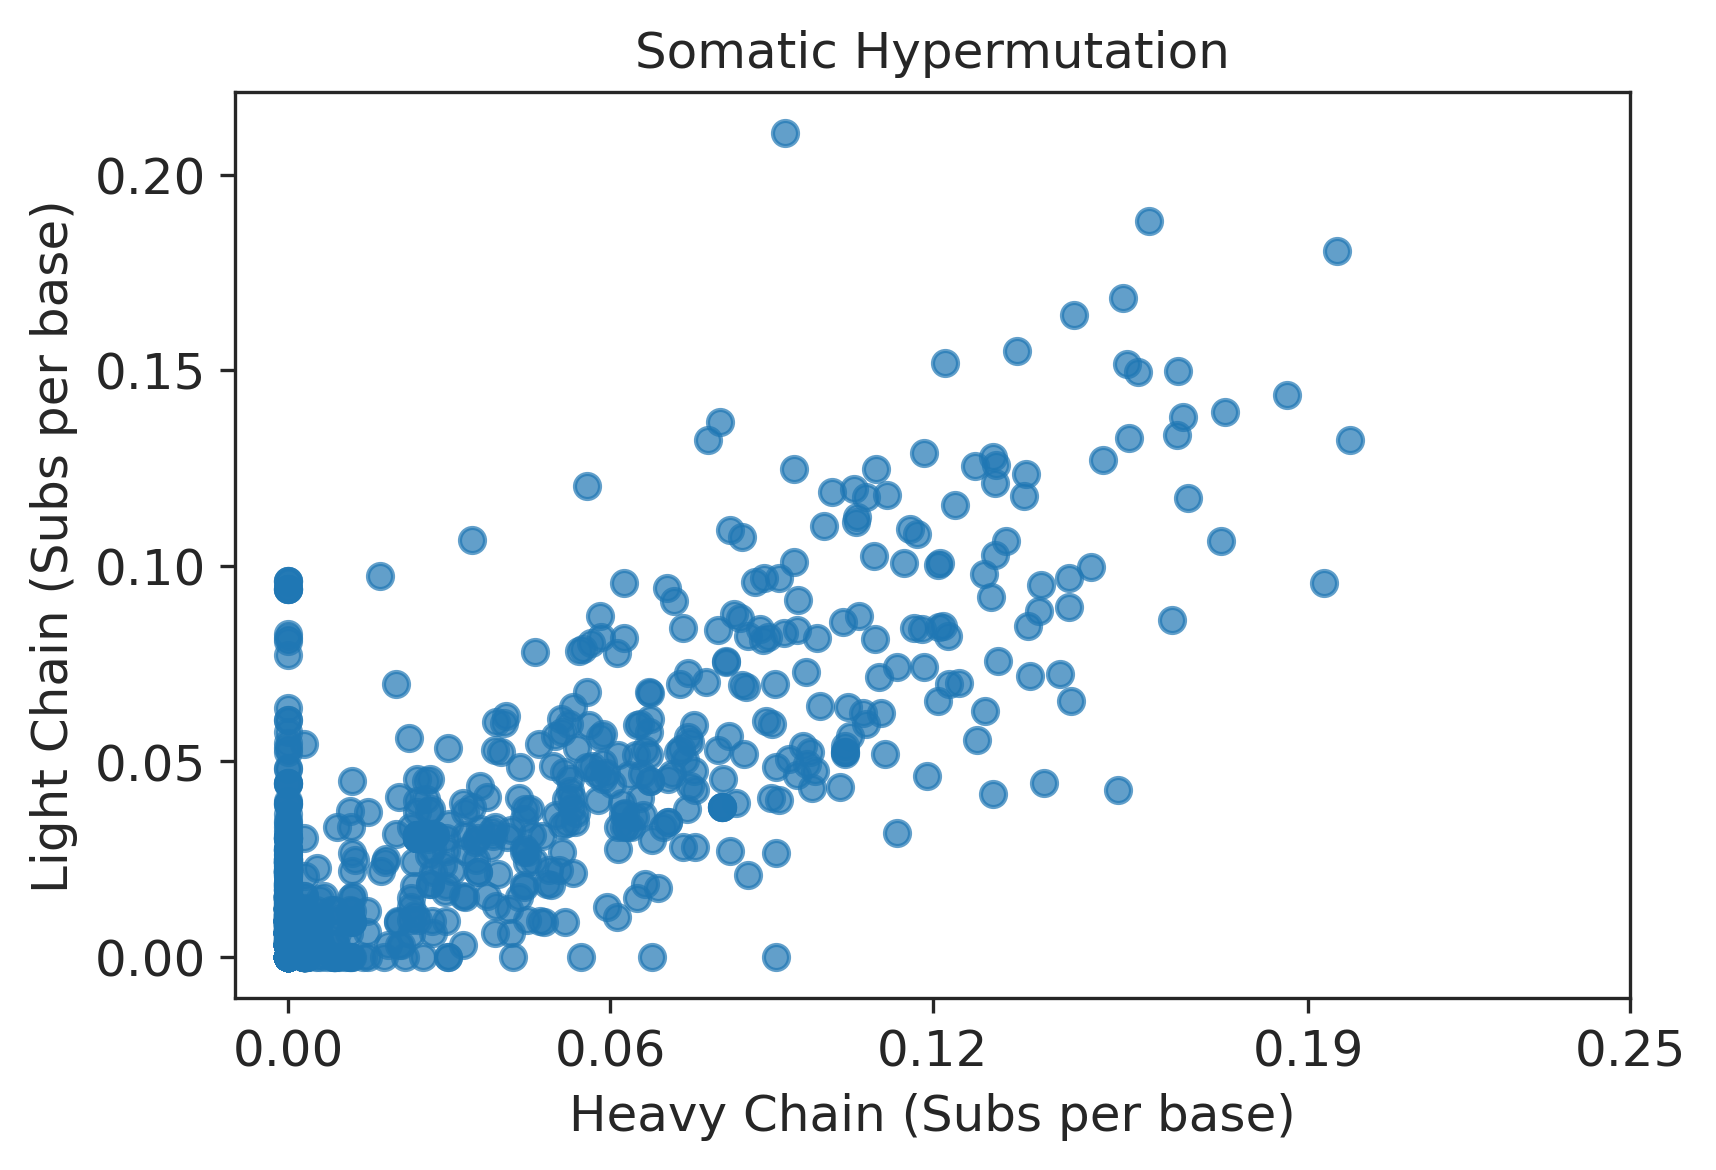

In [15]:
HeavyChainFreq = changeodb_H['MU_FREQ']
LightChainFreq = changeo_KL['MU_FREQ']

fig, ax = plt.subplots(1,1)
x = HeavyChainFreq
y = LightChainFreq
plt.scatter(x = x, y = y, alpha=0.7)
plt.xlabel('Heavy Chain (Subs per base)')
plt.ylabel('Light Chain (Subs per base)')
plt.xticks(np.round(np.linspace(0, 0.25, 5), decimals=2))
plt.title("Somatic Hypermutation")

scipy.stats.spearmanr(HeavyChainFreq, LightChainFreq)

save_figure(fig, 'HyperMutationAllCells.pdf', output_dir='figures')

SpearmanrResult(correlation=0.7005868674496835, pvalue=3.340077048370925e-33)
(0.7094234899576143, 2.3288744711273277e-34)


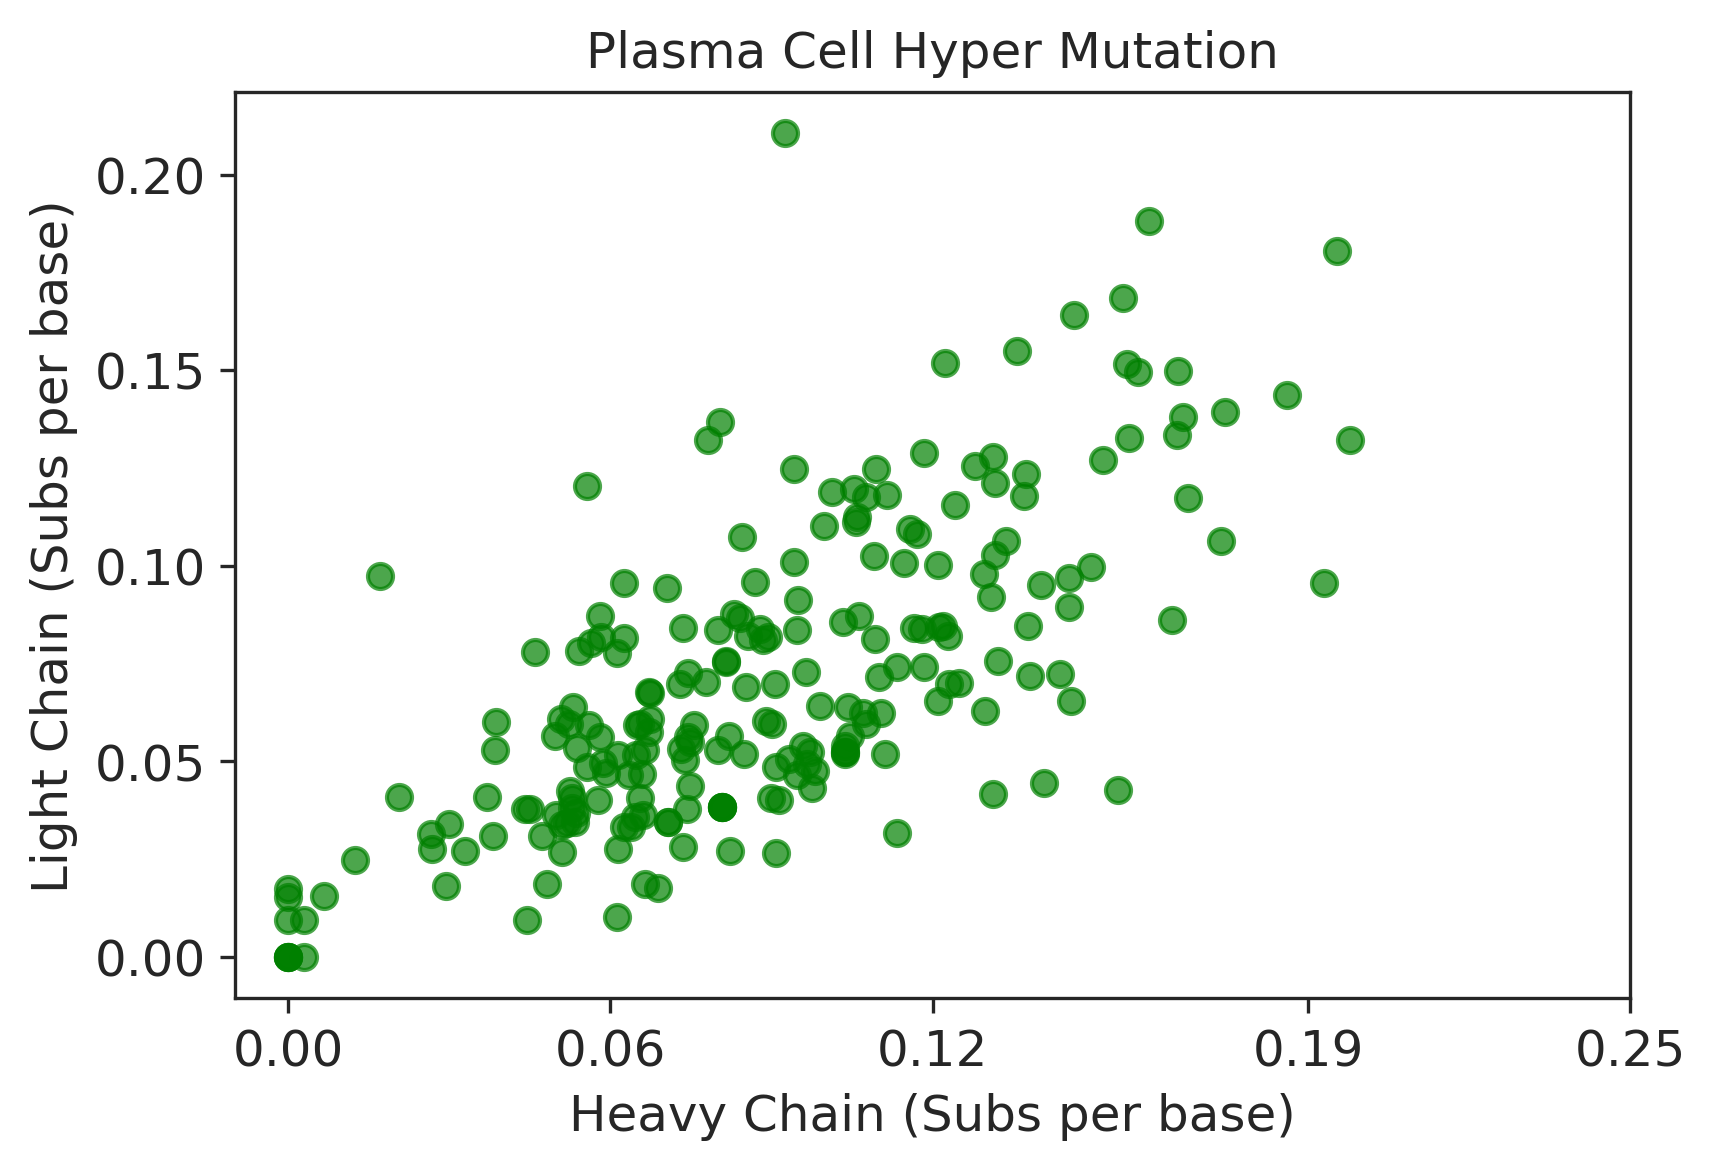

In [16]:
# Unncesssary but still here for now
data = mergedchangeos

_df = data[data.Donor == 'SS2_TS']

fig, ax = plt.subplots(1,1)
x = _df['MU_FREQ'][_df['LOCUS'] == 'IGH']
y = _df['MU_FREQ'][_df['LOCUS'] != 'IGH']
plt.scatter(x = x, y = y, alpha=0.7, color = 'g')
plt.xlabel('Heavy Chain (Subs per base)')
plt.ylabel('Light Chain (Subs per base)')
plt.xticks(np.round(np.linspace(0, 0.25, 5), decimals=2))
plt.title("Plasma Cell Hyper Mutation")
save_figure(fig, 'HyperMutationPlasmaCells', output_dir='figures')
print(scipy.stats.spearmanr(x, y))
print(scipy.stats.pearsonr(x,y))

In [21]:
_df.columns

Index(['Donor', 'CELL', 'SEQUENCE_ID', 'SEQUENCE_INPUT', 'FUNCTIONAL', 'IN_FRAME', 'STOP', 'MUTATED_INVARIANT', 'INDELS', 'LOCUS', 'V_CALL', 'D_CALL', 'J_CALL', 'SEQUENCE_VDJ', 'SEQUENCE_IMGT', 'V_SEQ_START', 'V_SEQ_LENGTH', 'V_GERM_START_VDJ', 'V_GERM_LENGTH_VDJ', 'V_GERM_START_IMGT', 'V_GERM_LENGTH_IMGT', 'NP1_LENGTH', 'D_SEQ_START', 'D_SEQ_LENGTH', 'D_GERM_START', 'D_GERM_LENGTH', 'NP2_LENGTH', 'J_SEQ_START', 'J_SEQ_LENGTH', 'J_GERM_START', 'J_GERM_LENGTH', 'JUNCTION', 'JUNCTION_LENGTH', 'GERMLINE_IMGT', 'V_SCORE', 'V_IDENTITY', 'V_EVALUE', 'V_CIGAR', 'D_SCORE', 'D_IDENTITY', 'D_EVALUE', 'D_CIGAR', 'J_SCORE', 'J_IDENTITY', 'J_EVALUE', 'J_CIGAR', 'FWR1_IMGT', 'FWR2_IMGT', 'FWR3_IMGT', 'FWR4_IMGT', 'CDR1_IMGT', 'CDR2_IMGT', 'CDR3_IMGT', 'CLONE', 'GERMLINE_IMGT_D_MASK', 'GERMLINE_V_CALL', 'GERMLINE_D_CALL', 'GERMLINE_J_CALL', 'MU_COUNT_SEQ_R', 'MU_COUNT_SEQ_S', 'MU_FREQ_SEQ_R', 'MU_FREQ_SEQ_S', 'MU_FREQ', 'MU_COUNT'], dtype='object')

SpearmanrResult(correlation=0.134306674363605, pvalue=0.00010298572077241786)
(0.33971551255245486, 6.803842502073743e-24)


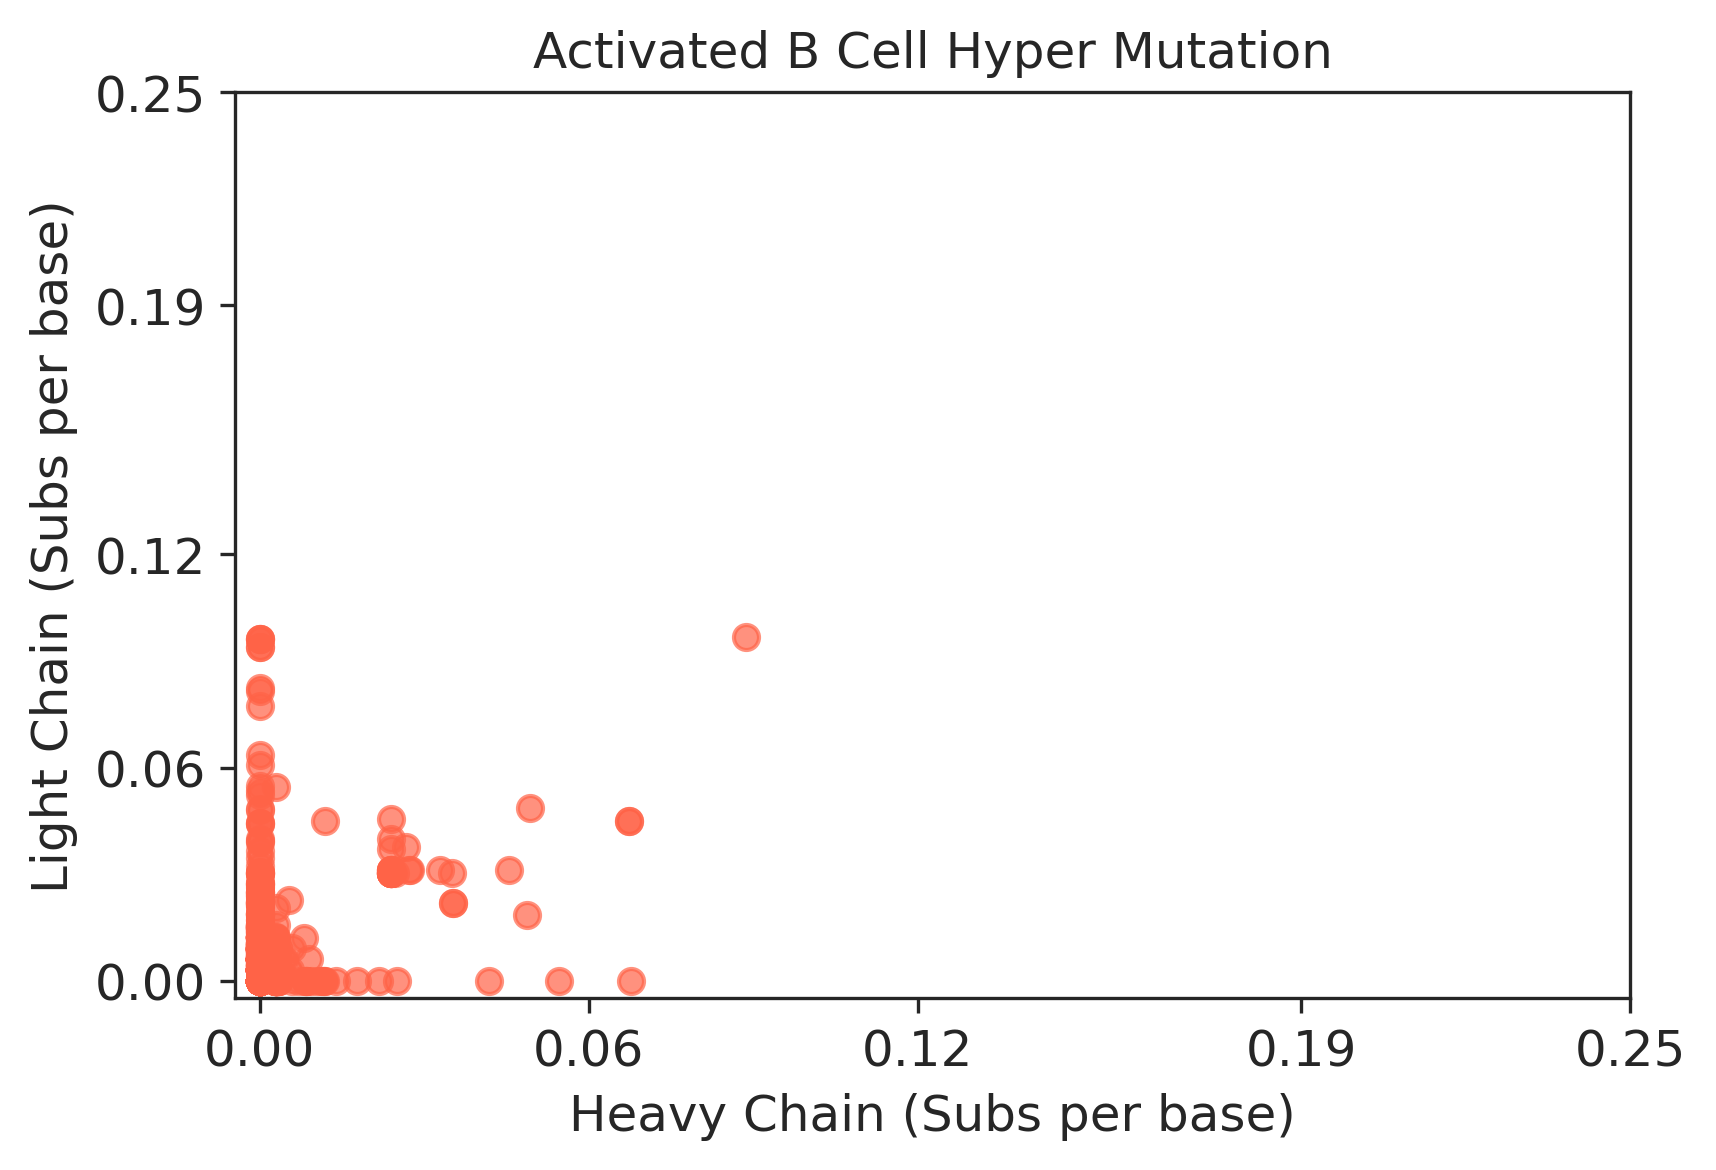

In [20]:
# Just the B cells I got, seems Felix's were previously hypermutated 
_df = data[data.Donor.isin(['Donor_1', 'Donor_2'])]
_df = _df[~_df.CELL.str.contains('Naive')]
x = _df['MU_FREQ'][_df['LOCUS'] == 'IGH']
y = _df['MU_FREQ'][_df['LOCUS'] != 'IGH']

plt.scatter(x = x, y = y, alpha=0.7, color= 'tomato')
plt.xlabel('Heavy Chain (Subs per base)')
plt.ylabel('Light Chain (Subs per base)')
plt.xticks(np.round(np.linspace(0, 0.25, 5), decimals=2))
plt.title("Activated B Cell Hyper Mutation")
plt.yticks(np.round(np.linspace(0, 0.25, 5), decimals=2))

save_figure(fig, 'HyperMutationActivatedCells.pdf', output_dir='figures')

print(scipy.stats.spearmanr(x, y))
print(scipy.stats.pearsonr(x, y))

In [31]:
# Are the more mutated cells in this plot likely contaminants 
_df.sort_values('MU_FREQ', ascending=False)
ab_tx, switch_tx = ut.loadSJoutIGH("../../../SharedData/" + 'CombinedSJouts_chr14_IGH.fthr')

filtering SJout to just IGH locus
making SJTable human readable


In [32]:
isotype_calls = ut.callIsotypeBySJout(ab_tx, plot=False)

isotype_calls.shape

isotypes = isotype_calls.drop_duplicates('cell')

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/pandas/core/indexing.py:845: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = _infer_fill_value(value)
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/pandas/core/indexing.py:966: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


In [33]:
isotype_calls.groupby('cell').exon_simple.value_counts()

cell                        exon_simple
AgSeqPooled_A11             IGHM           1
AgSeqPooled_A12             IGHM           1
AgSeqPooled_A7              IGHM           1
AgSeqPooled_A9              IGHA1          1
AgSeqPooled_B10             IGHM           1
                                          ..
PASL_5_PA_15_plate_2mod_H2  IGHA1          1
PASL_5_PA_15_plate_2mod_H5  IGHA1          1
PASL_5_PA_15_plate_2mod_H6  IGHM           1
PASL_5_PA_15_plate_2mod_H7  IGHA1          1
PASL_5_PA_15_plate_2mod_H8  IGHM           1
Name: exon_simple, Length: 2837, dtype: int64

In [34]:
splice_changeo = pd.merge(data, isotypes, left_on='CELL', right_on='cell' )


In [35]:
switched_cells = ab_tx[ab_tx.exon_simple.isin(['IGHG1', "IGHG2", 'IGHG3', 'IGHG4', 'IGHE'])].cell

In [36]:
ab_tx.groupby('cell').exon_simple.value_counts()

cell                        exon_simple
AgSeqPooled_A11             IGHM           1
AgSeqPooled_A12             IGHM           1
AgSeqPooled_A7              IGHD           1
                            IGHM           1
AgSeqPooled_A9              IGHA1          3
                                          ..
PASL_5_PA_15_plate_2mod_H5  IGHA1          3
PASL_5_PA_15_plate_2mod_H6  IGHG3          1
                            IGHM           1
PASL_5_PA_15_plate_2mod_H7  IGHA1          3
PASL_5_PA_15_plate_2mod_H8  IGHM           2
Name: exon_simple, Length: 4636, dtype: int64

ValueError: x and y must be the same size

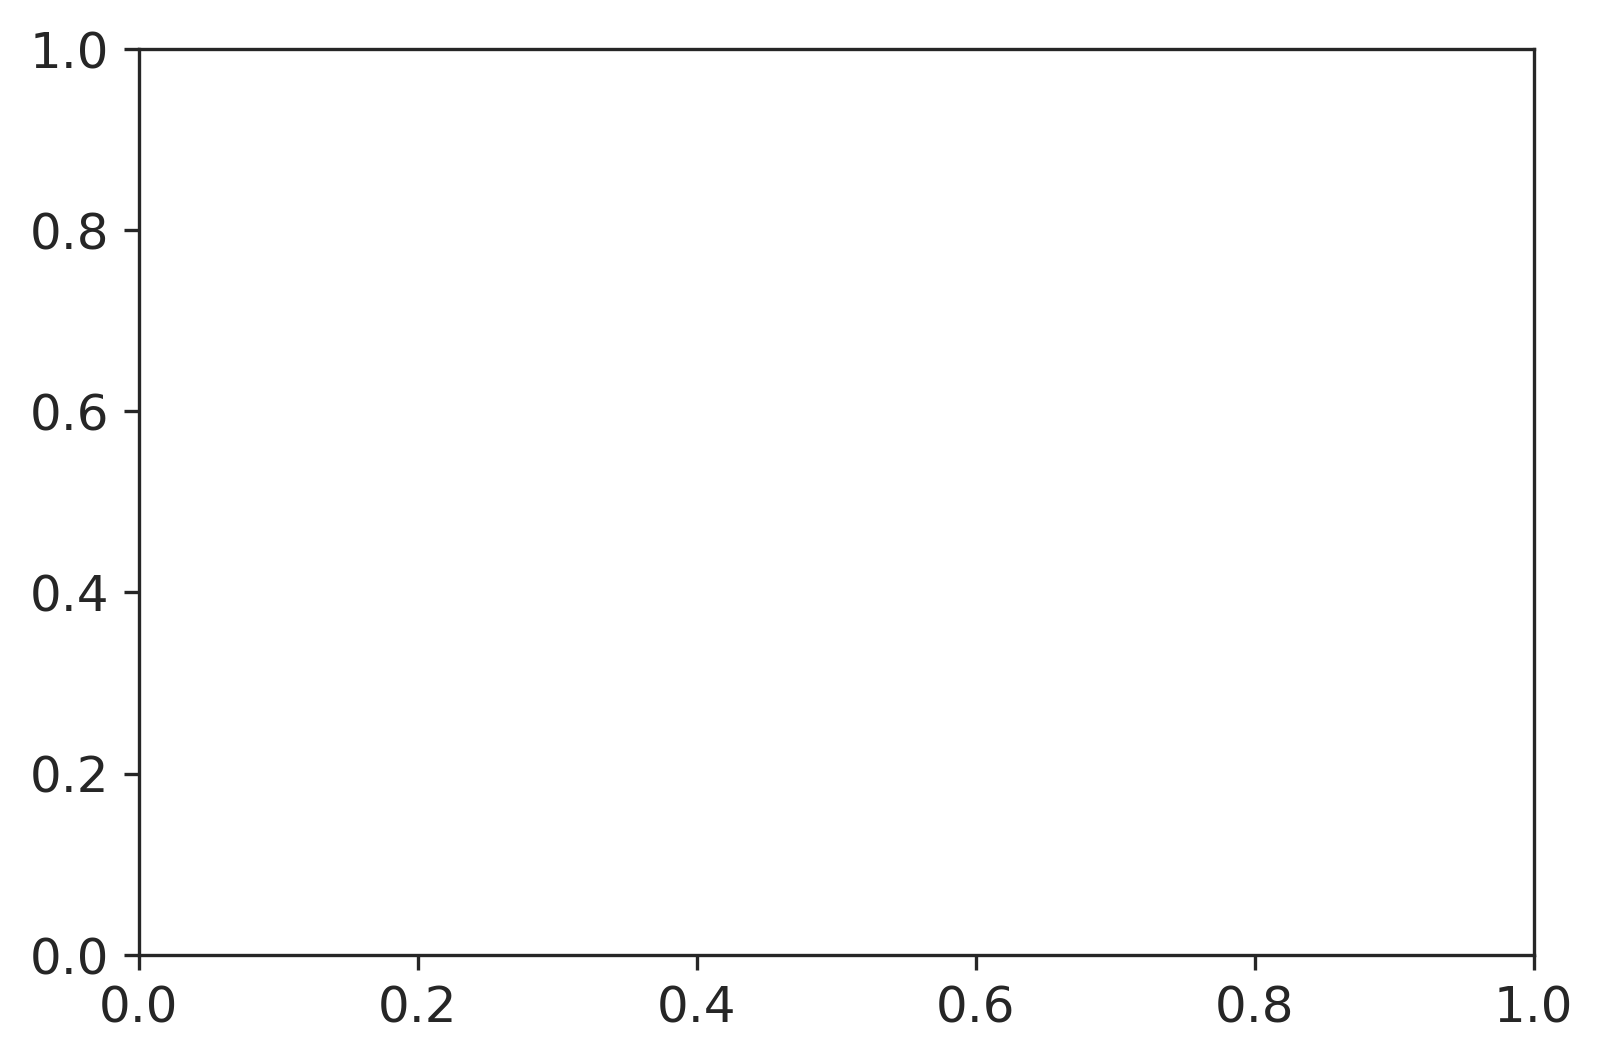

In [37]:
# Just the B cells I got, seems Felix's were previously hypermutated 
# Filtering out the IgHA contaminants
_df = splice_changeo[splice_changeo.Donor.isin(['Donor_1', 'Donor_2'])]
_df = _df[~_df.CELL.str.contains('Naive')]
_df = _df[~_df.ISOTYPE_by_splice.str.contains('IGHA')]
_df = _df[~_df.ISOTYPE_by_splice.str.contains('IGHG')]

x = _df['MU_FREQ'][_df['LOCUS'] == 'IGH']
y = _df['MU_FREQ'][_df['LOCUS'] != 'IGH']
fig, ax = plt.subplots(1,1)
plt.scatter(x = x, y = y, alpha=0.7)
plt.xlabel('Heavy Chain (Subs per base)')
plt.ylabel('Light Chain (Subs per base)')
plt.xticks(np.round(np.linspace(0, 0.2, 5), decimals=2))
plt.title("Activated B Cell Mutation")
save_figure(fig, 'HyperMutationActivatedCells.pdf', output_dir='figures')

print(scipy.stats.spearmanr(x, y))
print(scipy.stats.pearsonr(x, y))

In [94]:
## Naive B cells

SpearmanrResult(correlation=0.0429318023072724, pvalue=0.4535540791071039)
(0.07503194904219344, 0.18980643496259283)


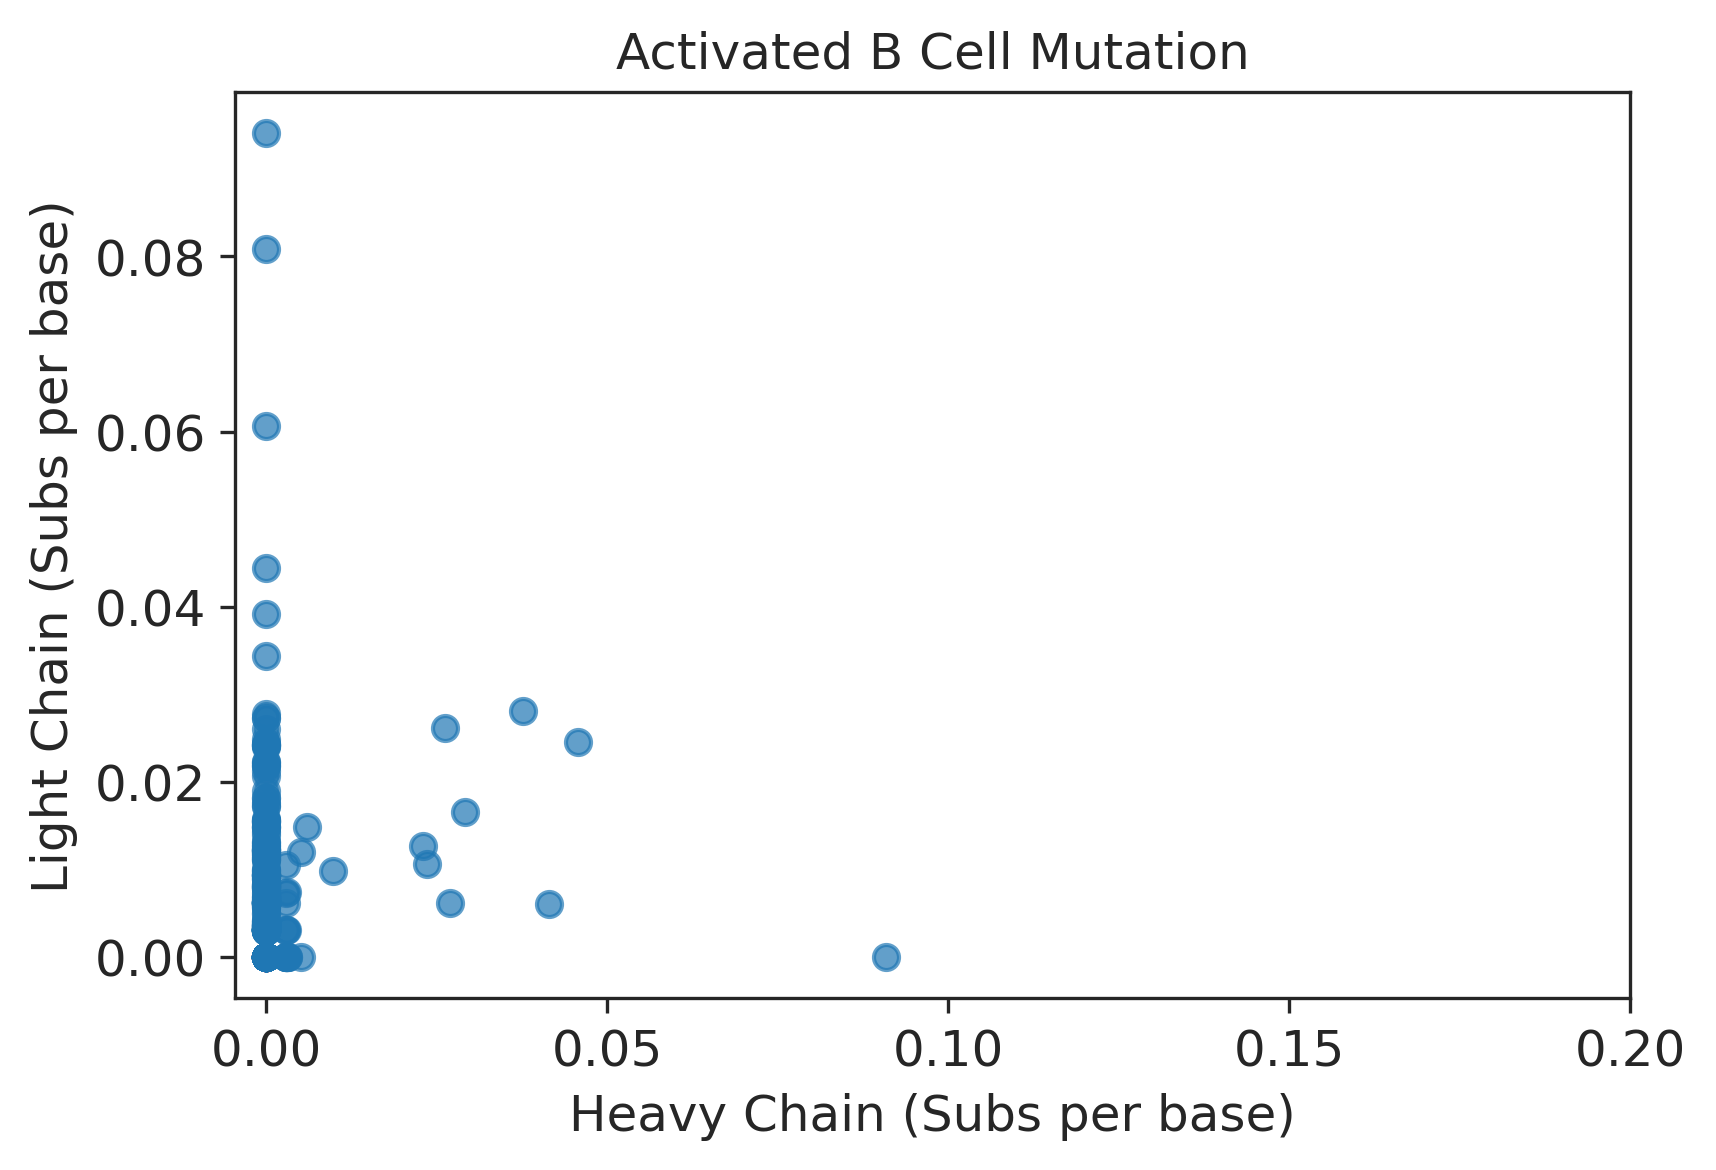

In [95]:
# Just the B cells I got, seems Felix's were previously hypermutated 
# Filtering out the IgHA contaminants
_df = splice_changeo
_df = _df[_df.CELL.str.contains('Naive')]
_df = _df[~_df.ISOTYPE_by_splice.str.contains('IGHA')]
_df = _df[~_df.ISOTYPE_by_splice.str.contains('IGHG')]

x = _df['MU_FREQ'][_df['LOCUS'] == 'IGH']
y = _df['MU_FREQ'][_df['LOCUS'] != 'IGH']
fig, ax = plt.subplots(1,1)
plt.scatter(x = x, y = y, alpha=0.7)
plt.xlabel('Heavy Chain (Subs per base)')
plt.ylabel('Light Chain (Subs per base)')
plt.xticks(np.round(np.linspace(0, 0.2, 5), decimals=2))
plt.title("Activated B Cell Mutation")
save_figure(fig, 'HyperMutationNaive.pdf', output_dir='figures')

print(scipy.stats.spearmanr(x, y))
print(scipy.stats.pearsonr(x, y))

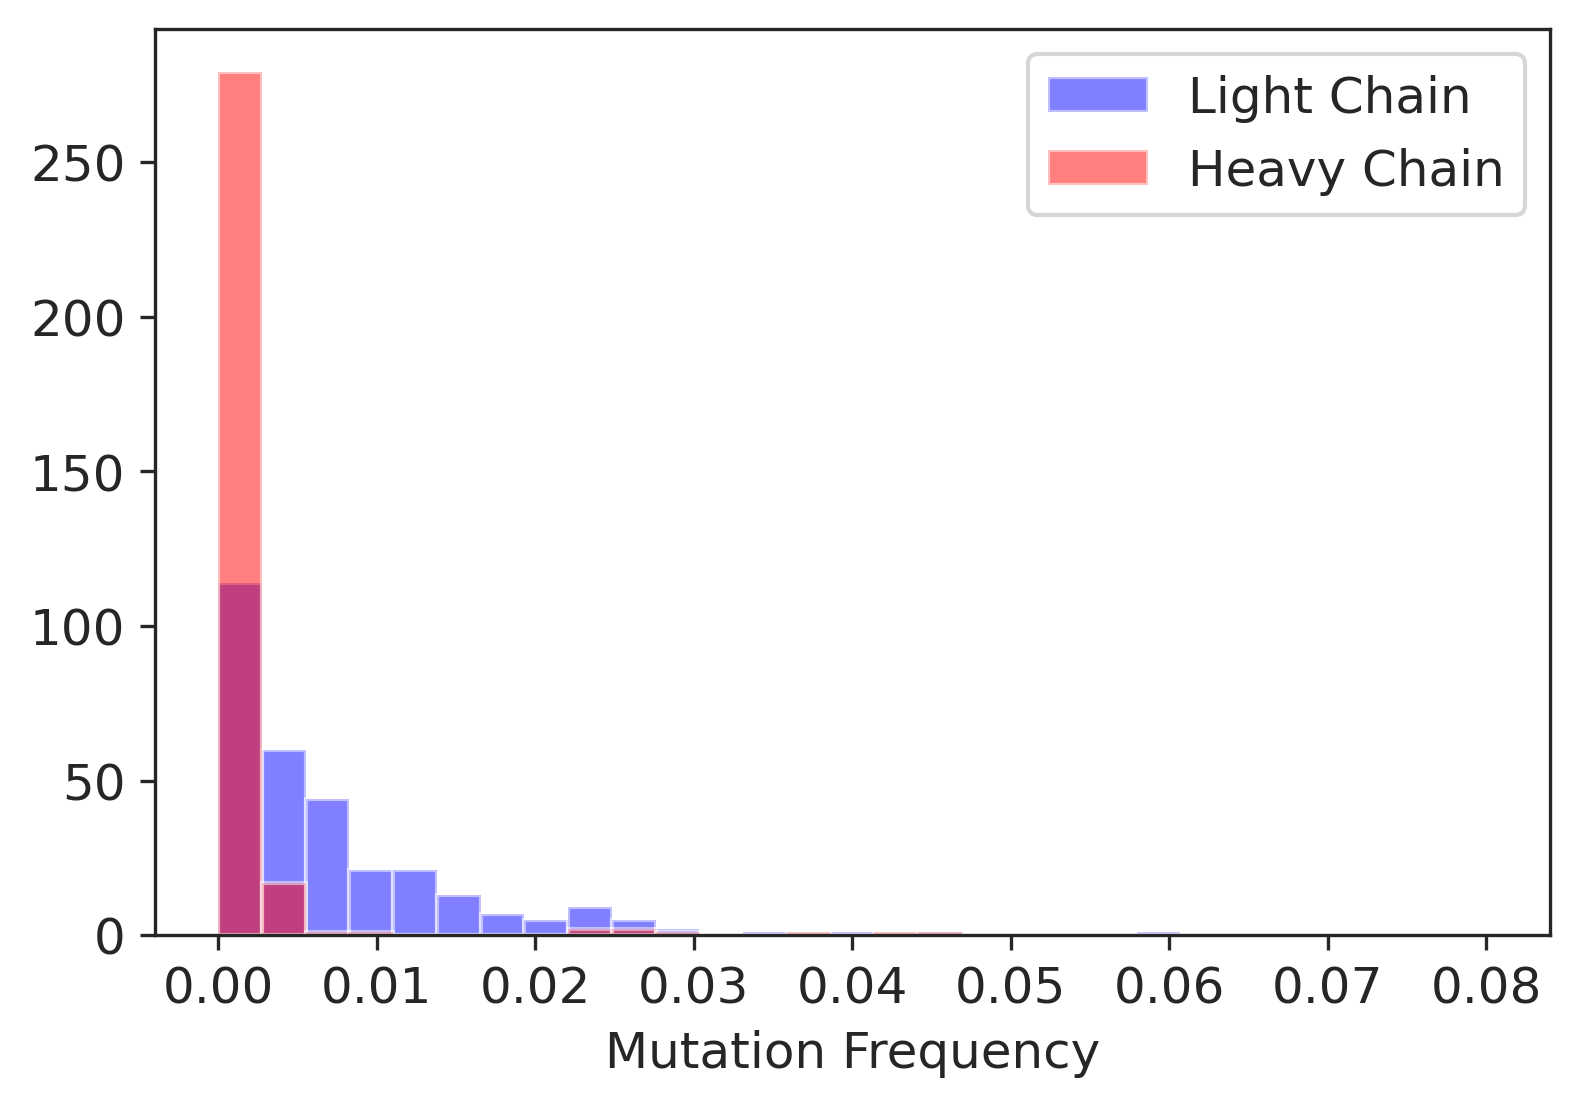

In [96]:
fig, ax = plt.subplots(1,1)

Light = _df['MU_FREQ'][_df['LOCUS'] != 'IGH']
Heavy = _df['MU_FREQ'][_df['LOCUS'] == 'IGH']
bins = np.linspace(0,0.08, 30)
plt.hist(Light, color='b', alpha = 0.5, bins = bins)
plt.hist(Heavy, color = 'r', alpha = 0.5, bins = bins)
plt.legend(['Light Chain', 'Heavy Chain'
])
plt.xlabel('Mutation Frequency')
stat, pval = scipy.stats.wilcoxon(Light, Heavy)
save_figure(fig, "LcHcMutationNaiveDistributions.pdf", output_dir='figures')
#plt.text(0.06, 450, "Wilcoxon:" + str(np.round(pval, decimals=3)))

## Gene Expression and Hypermutation

In [38]:
# Try to remove the ERCCs
adata = sc.read_h5ad(data_dir + 'Combined_PC.h5ad')

# Remove the Batch key added by adata 
adata.obs.index = adata.obs.index.str[:-2]

_adata = adata

ERCCs = _adata.var.index[_adata.var.index.str.contains("ERCC-|NIST")].to_list()

_adata = _adata[:, ~_adata.var.index.isin(ERCCs)]

# Remove all the uninterpretable genes, these also seem to contribute the batch variability
UninterpretableGenes = _adata.var.index[_adata.var.index.str.contains(pat = 'AF[0-9]|AC[0-9]|AC[0-9]|AL[0-9]|AP[0-9]|FO[0-9]|ENSG', regex = True)].to_list()
_adata = _adata[:, ~_adata.var.index.isin(UninterpretableGenes)]

sc.pp.filter_cells(_adata, min_counts=80000, inplace=True)
sc.pp.filter_genes(_adata, min_cells=40, inplace=True)

sc.pp.normalize_total(_adata, exclude_highly_expressed=True, inplace=True, target_sum=1e6)

# Get raw df with cells and genes 

df = pd.DataFrame(_adata.X)
df.set_index(_adata.obs.index, inplace = True)
df.columns = _adata.var.index
# Log 10 transform it 
df_log = np.log10(df + 1)

Trying to set attribute `.obs` of view, copying.


In [39]:
sc.pp.calculate_qc_metrics(adata, inplace = True)

IGH_genes = ['AICDA','IGHM', 'IGHD', 'IGHA2', 'IGHA1', 'IGHG1', "IGHG2", 'IGHG4', 'IGHG3', 'IGHE']

df_GeneExpression = sc.get.obs_df(adata, keys = IGH_genes, use_raw=True)

In [82]:
# Use only my cells which I activated, exclude IGHA which are likely contaminants
data = mergedchangeos
data = data[data.Donor.isin(['Donor_1', 'Donor_2'])]
data = data[~data.CELL.str.contains('Naive')]

# filter to just IGH
data = data[data.LOCUS == 'IGH']

_df = pd.merge(df_log, data.groupby('CELL').sum()[['MU_FREQ', 'MU_COUNT']], left_index=True, right_on='CELL' )

#_df = _df[_df.MU_COUNT < 20]
#_df = _df[_df.AICDA > 0]

In [83]:
_df['log_MU_COUNT'] = np.log10(_df['MU_COUNT'] + 1)

SpearmanrResult(correlation=-0.03168424130733928, pvalue=0.363398212848288)
(-0.03019020014659156, 0.3864736491942193)


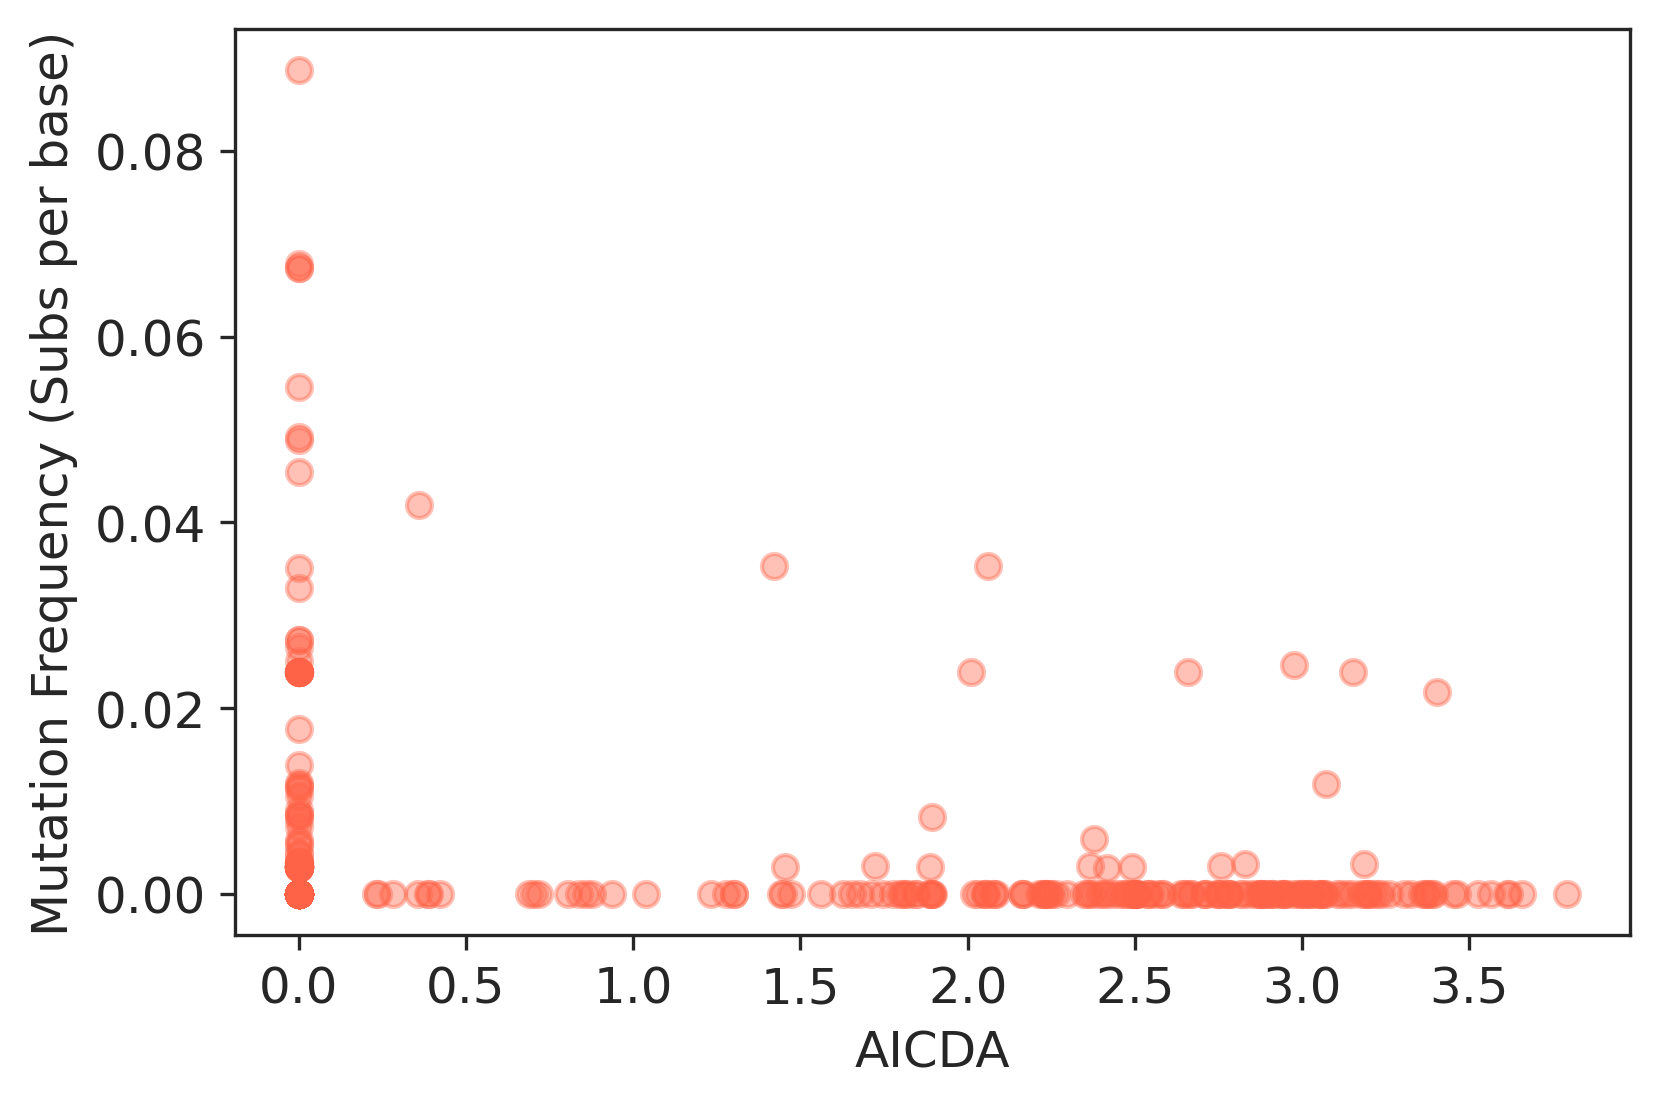

In [84]:
GOI = 'AICDA'

x = _df[GOI]
y = _df['MU_FREQ']

fig, ax = plt.subplots(1,1)

plt.scatter(x = x, y = y, alpha = 0.4, color = 'tomato')
plt.xlabel(GOI)
plt.ylabel('Mutation Frequency (Subs per base)')

save_figure(fig, 'AIDvsMutationCountActivated.pdf', output_dir='figures')

print(scipy.stats.spearmanr(x, y))
print(scipy.stats.pearsonr(x,y))

SpearmanrResult(correlation=-0.02560366113407468, pvalue=0.3886036459420765)
(-0.03491811623935369, 0.23960923936058096)


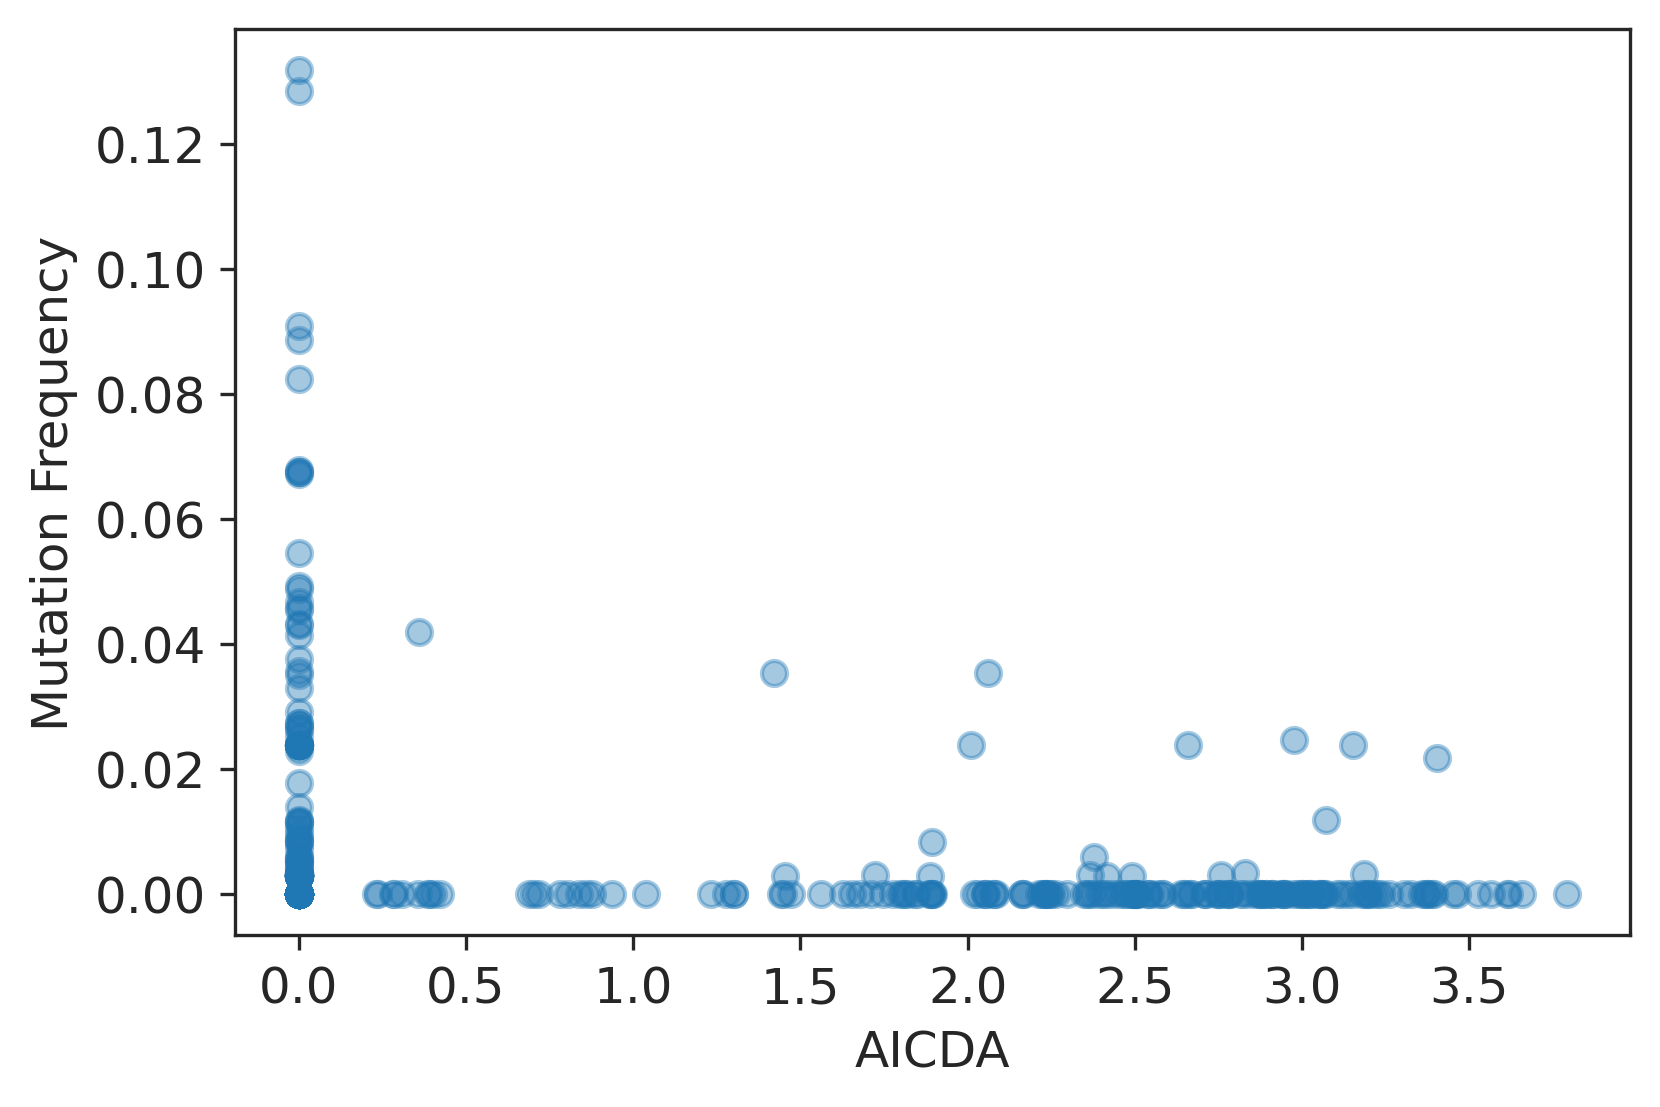

In [43]:
GOI = 'AICDA'

fig, ax = plt.subplots(1,1)

x = _df[GOI]
y = _df['MU_FREQ']
plt.scatter(x = x, y = y, alpha = 0.4)
plt.xlabel(GOI)
plt.ylabel('Mutation Frequency')
print(scipy.stats.spearmanr(x, y))
print(scipy.stats.pearsonr(x,y))

## Any relationship between class switching and AICDA expression?

In [60]:
_df = pd.merge(df_log, splice_changeo[splice_changeo.LOCUS == 'IGH'] , left_index=True, right_on='CELL' )


In [61]:
Activated_Merged = _df[_df.SAMPLE.isin(['Donor_1', 'Donor_2'])]
Activated_Merged = Activated_Merged[~Activated_Merged.ISOTYPE_by_splice.str.contains('IGHA')]
Activated_Merged = Activated_Merged[~Activated_Merged.cell.str.contains('Naive')]

In [62]:
Activated_Merged['Switched'] = ~Activated_Merged.ISOTYPE_by_splice.isin(['IGHM', 'IGHDM', 'IGHD'])

In [63]:
Activated_Merged['Switched_Permissive'] = Activated_Merged.cell.isin(switched_cells)

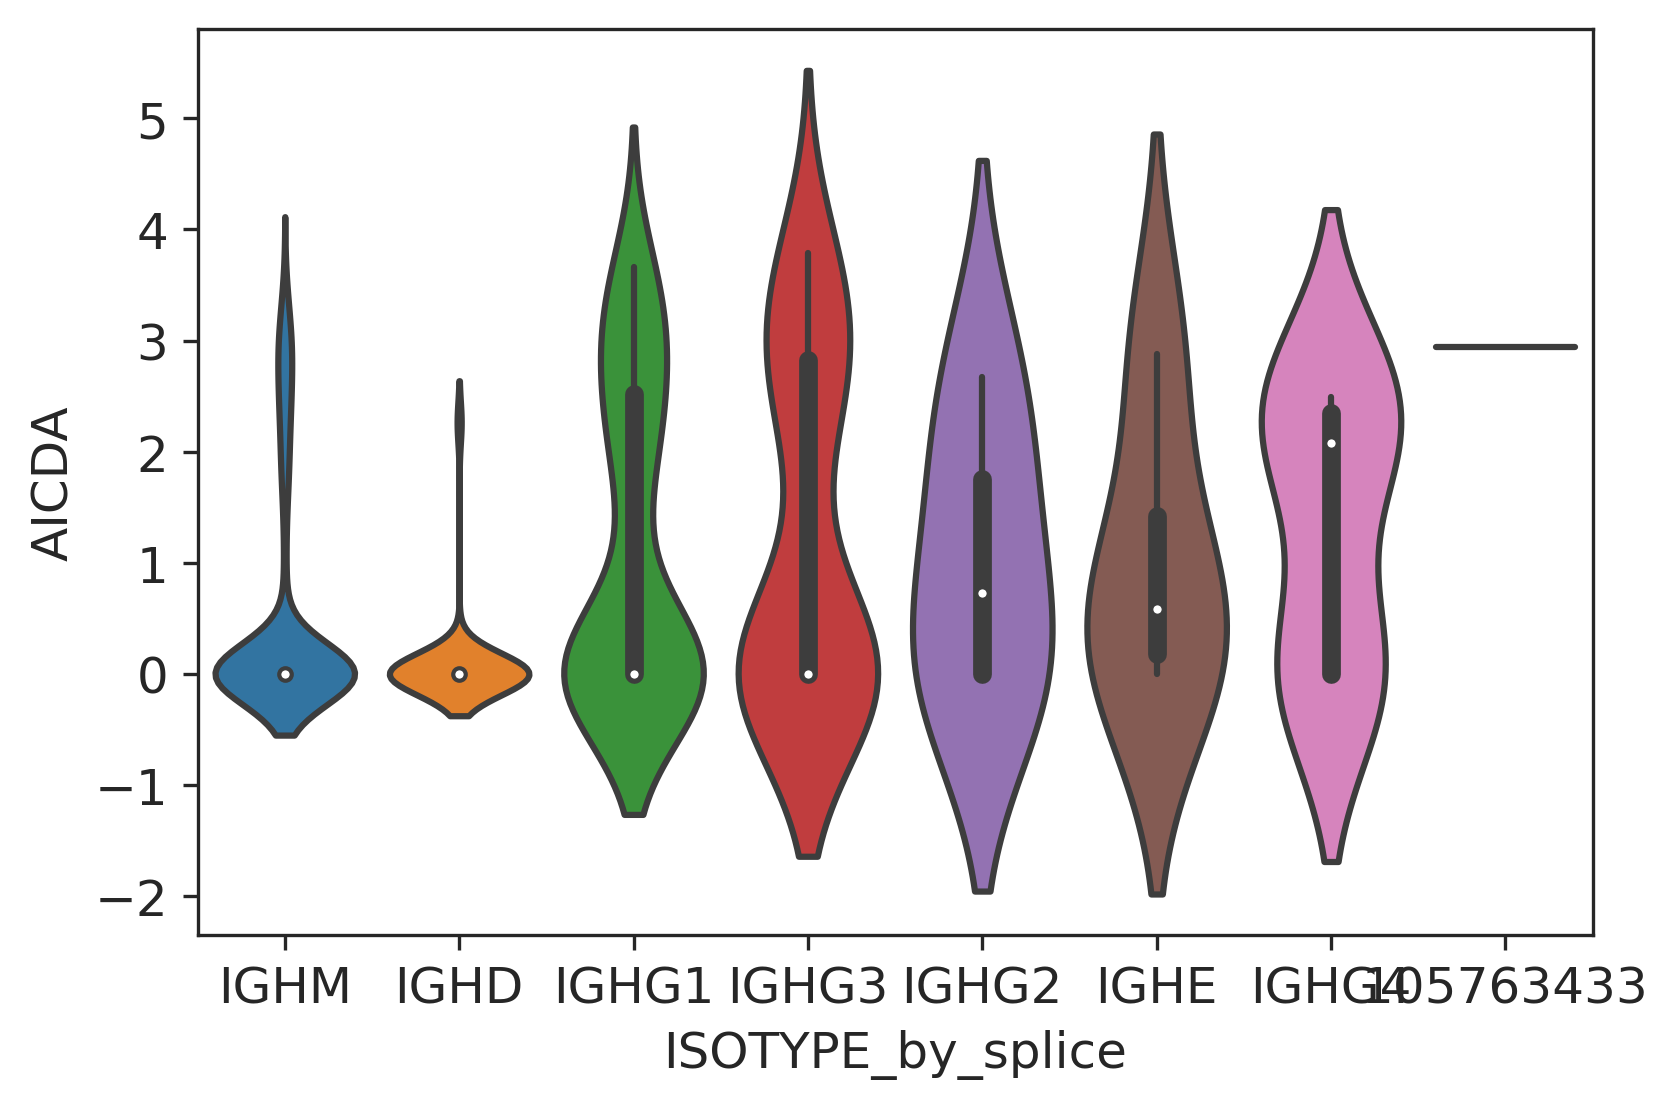

In [64]:
fig, ax = plt.subplots(1,1)

sns.violinplot(data = Activated_Merged, y = 'AICDA', x = 'ISOTYPE_by_splice', scale = 'width')


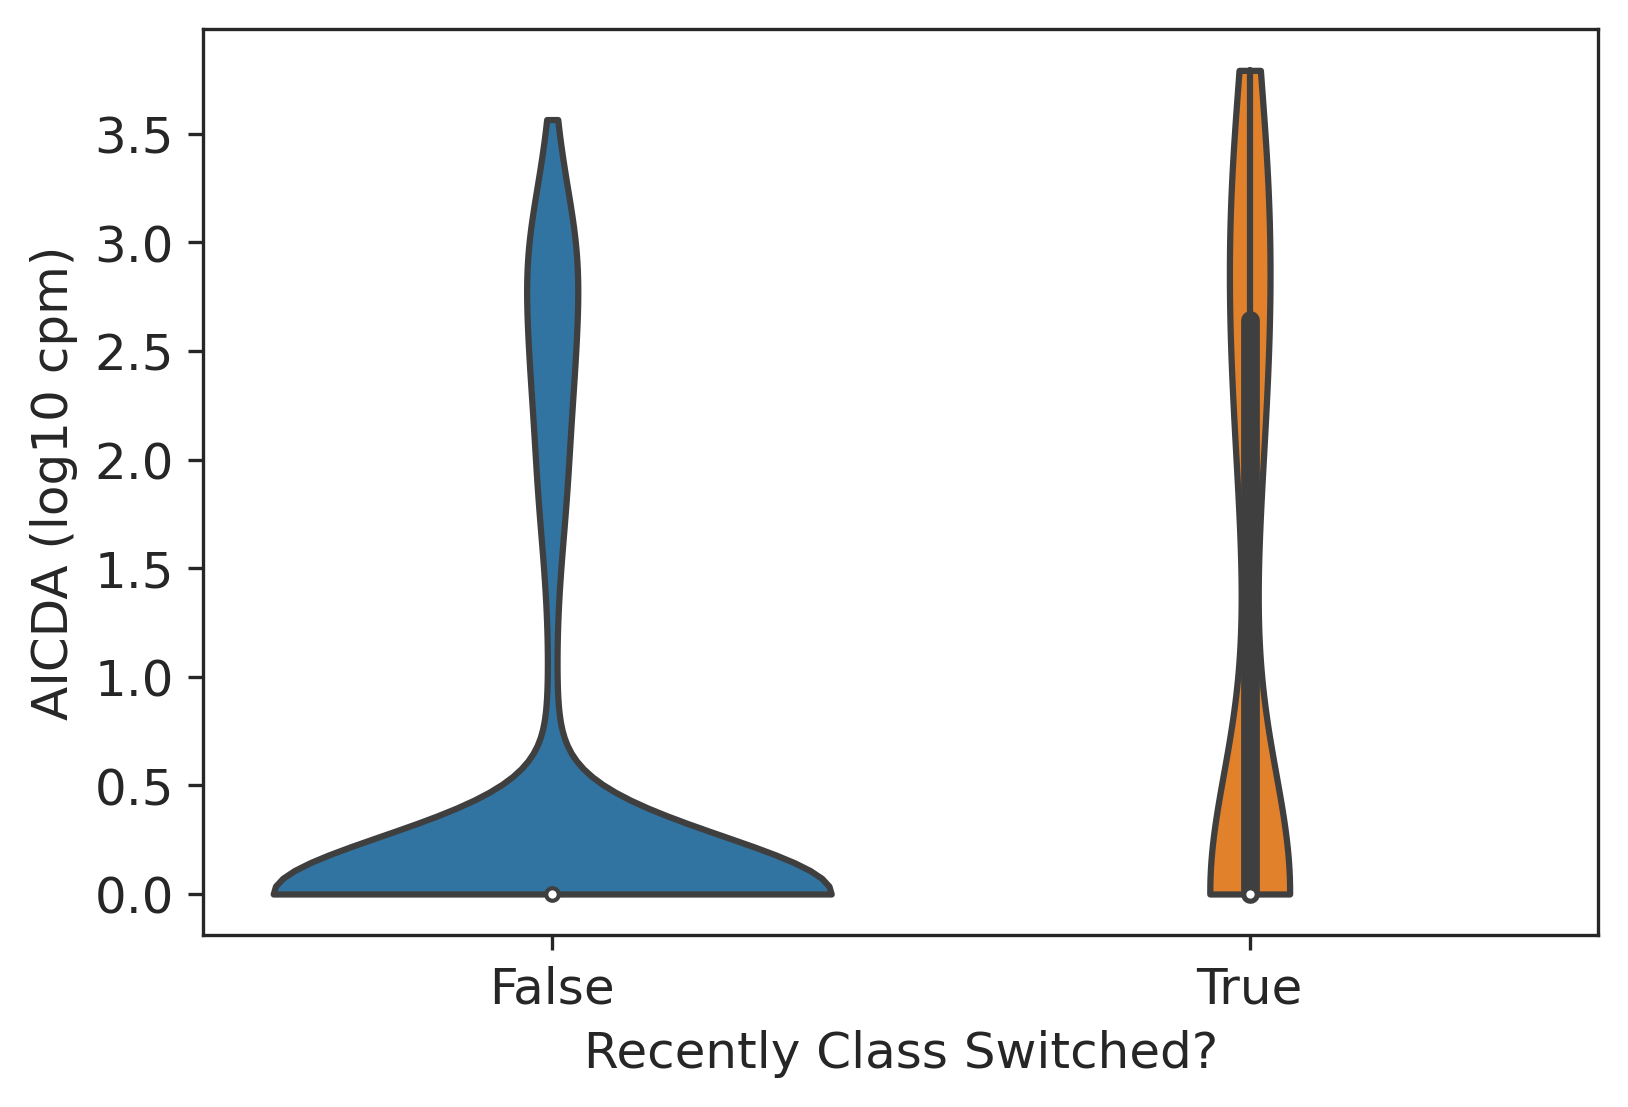

In [80]:
fig, ax = plt.subplots(1,1)

sns.violinplot(data = Activated_Merged, scale = 'count', y = 'AICDA', x = 'Switched_Permissive', cut = 0)

plt.ylabel('AICDA (log10 cpm)')
plt.xlabel('Recently Class Switched?')

save_figure(fig, 'AICDA_Expression_CSROutcome.pdf', output_dir='figures')

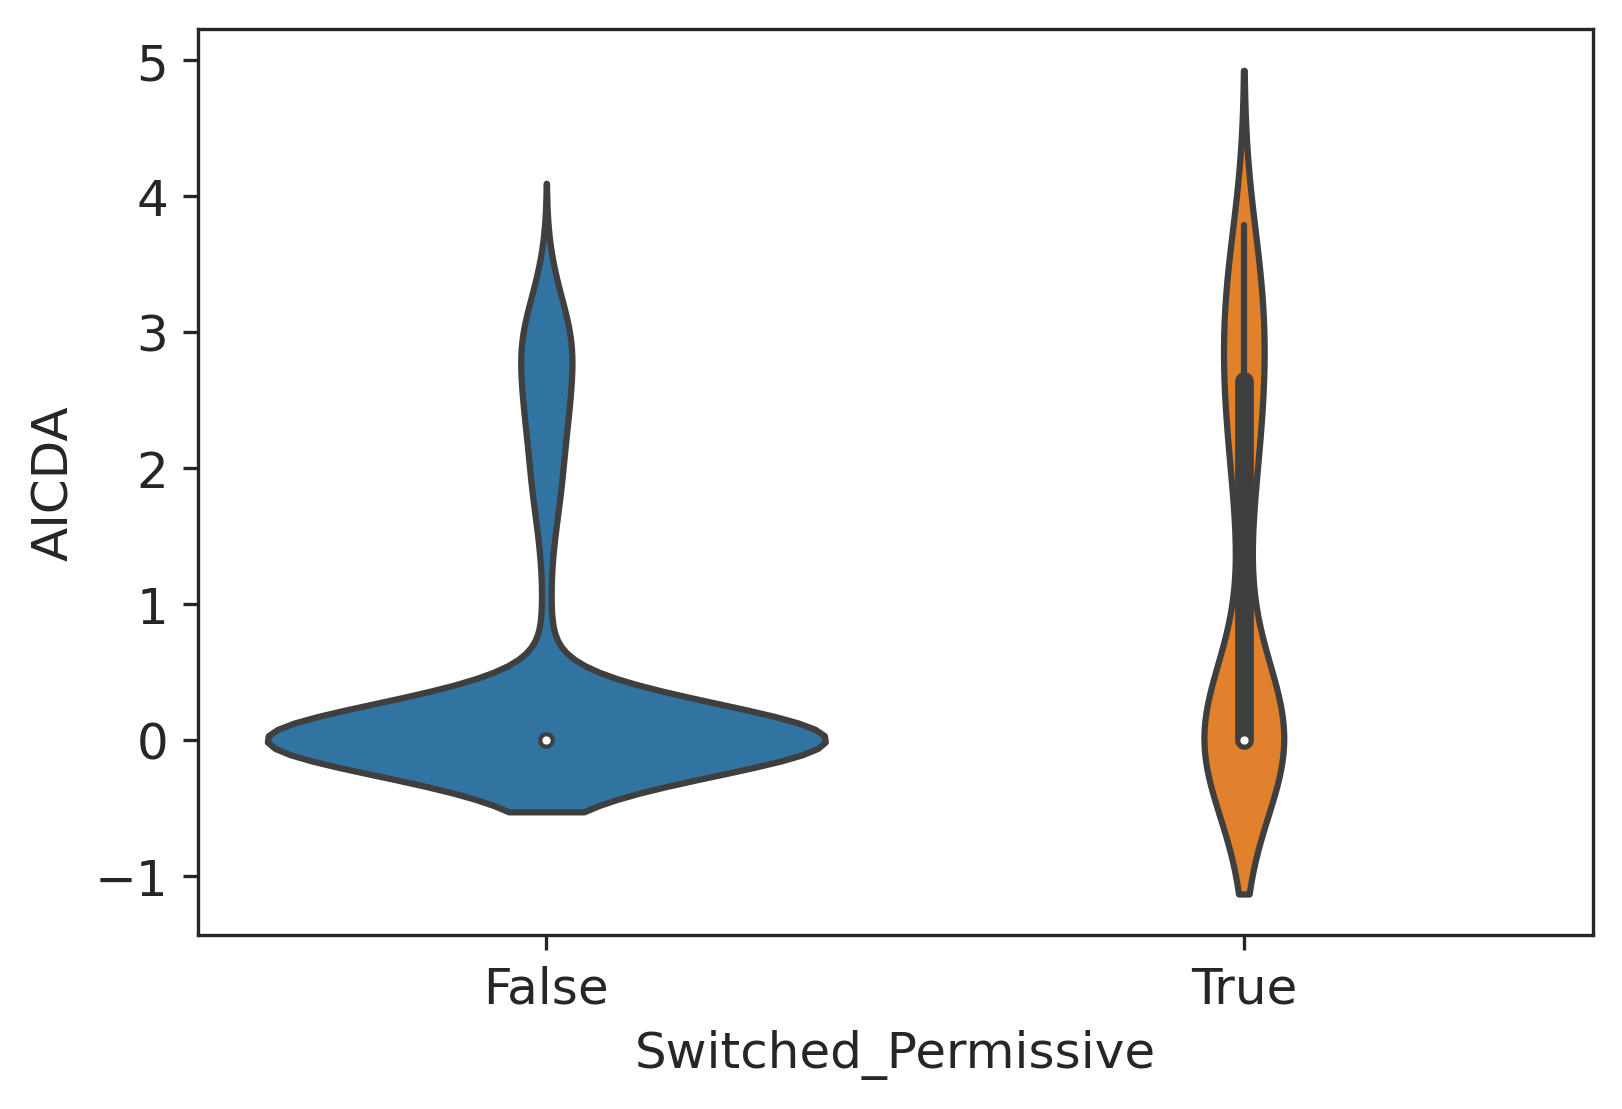

In [73]:
sns.violinplot(data = Activated_Merged, y = 'AICDA', x = 'Switched_Permissive', scale="count")


In [85]:
x = Activated_Merged['AICDA'][Activated_Merged.Switched_Permissive == True].values
y = Activated_Merged['AICDA'][Activated_Merged.Switched_Permissive == False].values

scipy.stats.kruskal(x, y)

KruskalResult(statistic=37.595280299788804, pvalue=8.705486856019516e-10)

In [68]:
x.shape

(99,)

In [69]:
y.shape

(692,)

In [105]:
# Use Numpy to do the Pearson Correllation of all values 
df_corr = np.corrcoef(_df.values, rowvar=False) 

# Put the labels back on and make it a df
df_corr = pd.DataFrame(df_corr, index = _df.columns, columns=_df.columns)

# Top 97 genes which are highly correlated with a high mutation load


/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/numpy/lib/function_base.py:2534: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/numpy/lib/function_base.py:2535: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


In [26]:
negs = df_corr['MU_FREQ'].sort_values(ascending = False)[-300:]
pos = df_corr['MU_FREQ'].sort_values(ascending = False)[:300]


In [27]:
subset_genes = pd.concat([negs, pos])

In [28]:
smallerdf = _df[(subset_genes.index)]

In [29]:
df_corrS = smallerdf.corr(method='spearman')

In [30]:
df_corrS['MU_FREQ'].sort_values(ascending=False)[:100]


MU_FREQ         1.000000
log_MU_COUNT    0.979722
MU_COUNT        0.979722
IGLV2-14        0.270213
IGLV2-34        0.200291
IGHV1-46        0.179846
IGLV1-47        0.179305
IGLC3           0.158146
IGLV1-44        0.148422
MT-CO2          0.144419
IGLV2-23        0.138997
TMSB10          0.138446
RPS15           0.135458
RPL13A          0.135277
IGLV2-18        0.135077
MTCO2P12        0.129746
RPS11           0.128335
RPS27           0.126294
RPL34P18        0.125945
RPL15P3         0.125874
RPS12           0.121369
RPL39P3         0.121038
RPS29           0.120833
RPL21P28        0.120516
BX679664.1      0.116571
RPL31           0.116179
RPL21           0.112900
CD52            0.112725
RPL18A          0.110700
TMSB4XP8        0.110639
RPS23P8         0.110363
RPL21P16        0.109590
RPS18           0.109204
RPS10P16        0.108207
HYKK            0.108026
MIPOL1          0.106969
RPLP2           0.106937
DLX6-AS1        0.105436
RPS18P12        0.104097
RPS18P9         0.103290


In [31]:
df_corrS['MU_FREQ'].sort_values(ascending=False)[-50:]

CCDC47       -0.098156
DAP          -0.098515
ATXN2L       -0.098717
RBBP4        -0.099017
PIM1         -0.100033
CARS         -0.100984
BCL3         -0.101275
RIOX2        -0.101363
DHCR24       -0.102530
DZIP3        -0.103157
SUPT7L       -0.103417
SMC1A        -0.103996
NET1         -0.104119
HIST1H3I     -0.104137
TRMU         -0.104187
CCNK         -0.104262
WDR1         -0.106095
DDX1         -0.107312
NRAS         -0.109235
SURF4        -0.109477
NFXL1        -0.109617
ERCC6L2      -0.110309
SLF2         -0.114610
RAB1B        -0.115003
TNFAIP3      -0.115286
PMM2         -0.115854
PAPSS1       -0.116655
NOD2         -0.117107
NCSTN        -0.118355
G3BP1        -0.118497
IFT74        -0.119499
CRELD2       -0.120366
PROSER1      -0.120695
MLX          -0.121013
CFI          -0.121735
CHMP5        -0.123179
HCFC1        -0.124325
PISD         -0.127584
IGKC         -0.128378
ACADM        -0.129706
LPXN         -0.130211
NUP107       -0.137049
AVL9         -0.141627
IGLV3-21   

In [195]:
_df = df_all_contig_annotations_valid_IGH.groupby("CLONE").sum()

(array([1.214e+03, 1.270e+02, 7.500e+01, 3.300e+01, 6.000e+00, 1.000e+00,
        0.000e+00, 4.000e+00, 0.000e+00, 1.000e+00]),
 array([0.        , 0.04376013, 0.08752027, 0.1312804 , 0.17504053,
        0.21880066, 0.2625608 , 0.30632093, 0.35008106, 0.3938412 ,
        0.43760133]),
 <a list of 10 Patch objects>)

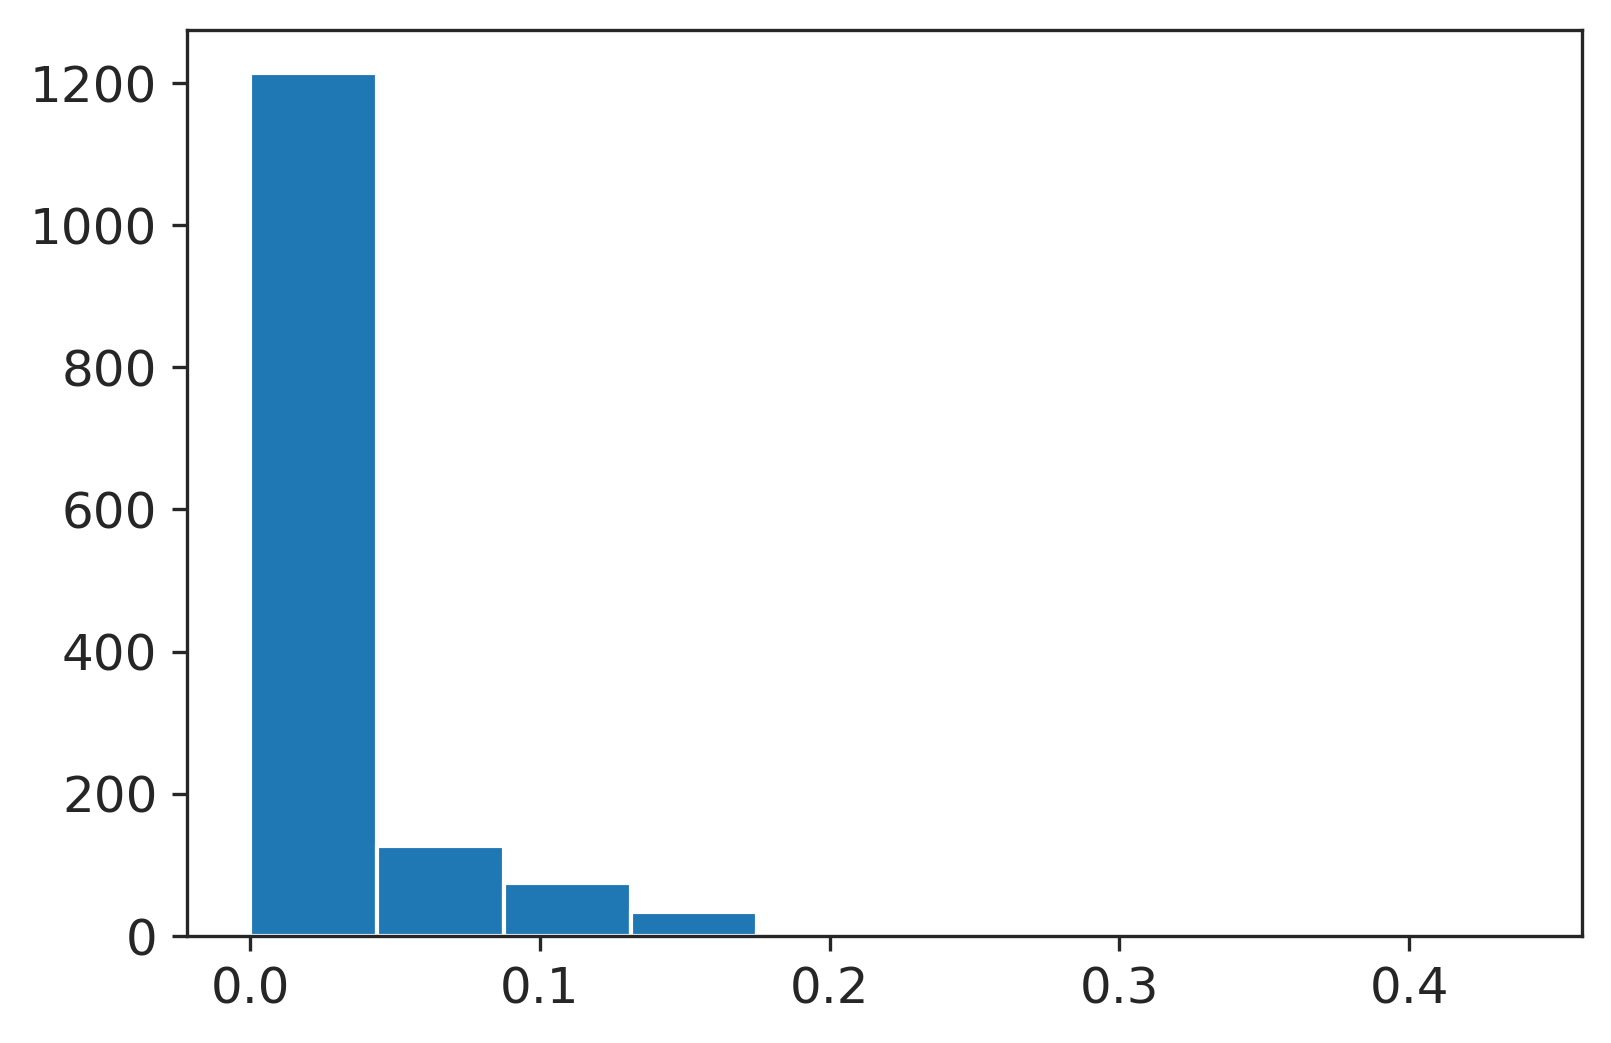

In [197]:
plt.hist(_df['MU_FREQ'])

(array([9., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.        , 0.04376013, 0.08752027, 0.1312804 , 0.17504053,
        0.21880066, 0.2625608 , 0.30632093, 0.35008106, 0.3938412 ,
        0.43760133]),
 <a list of 10 Patch objects>)

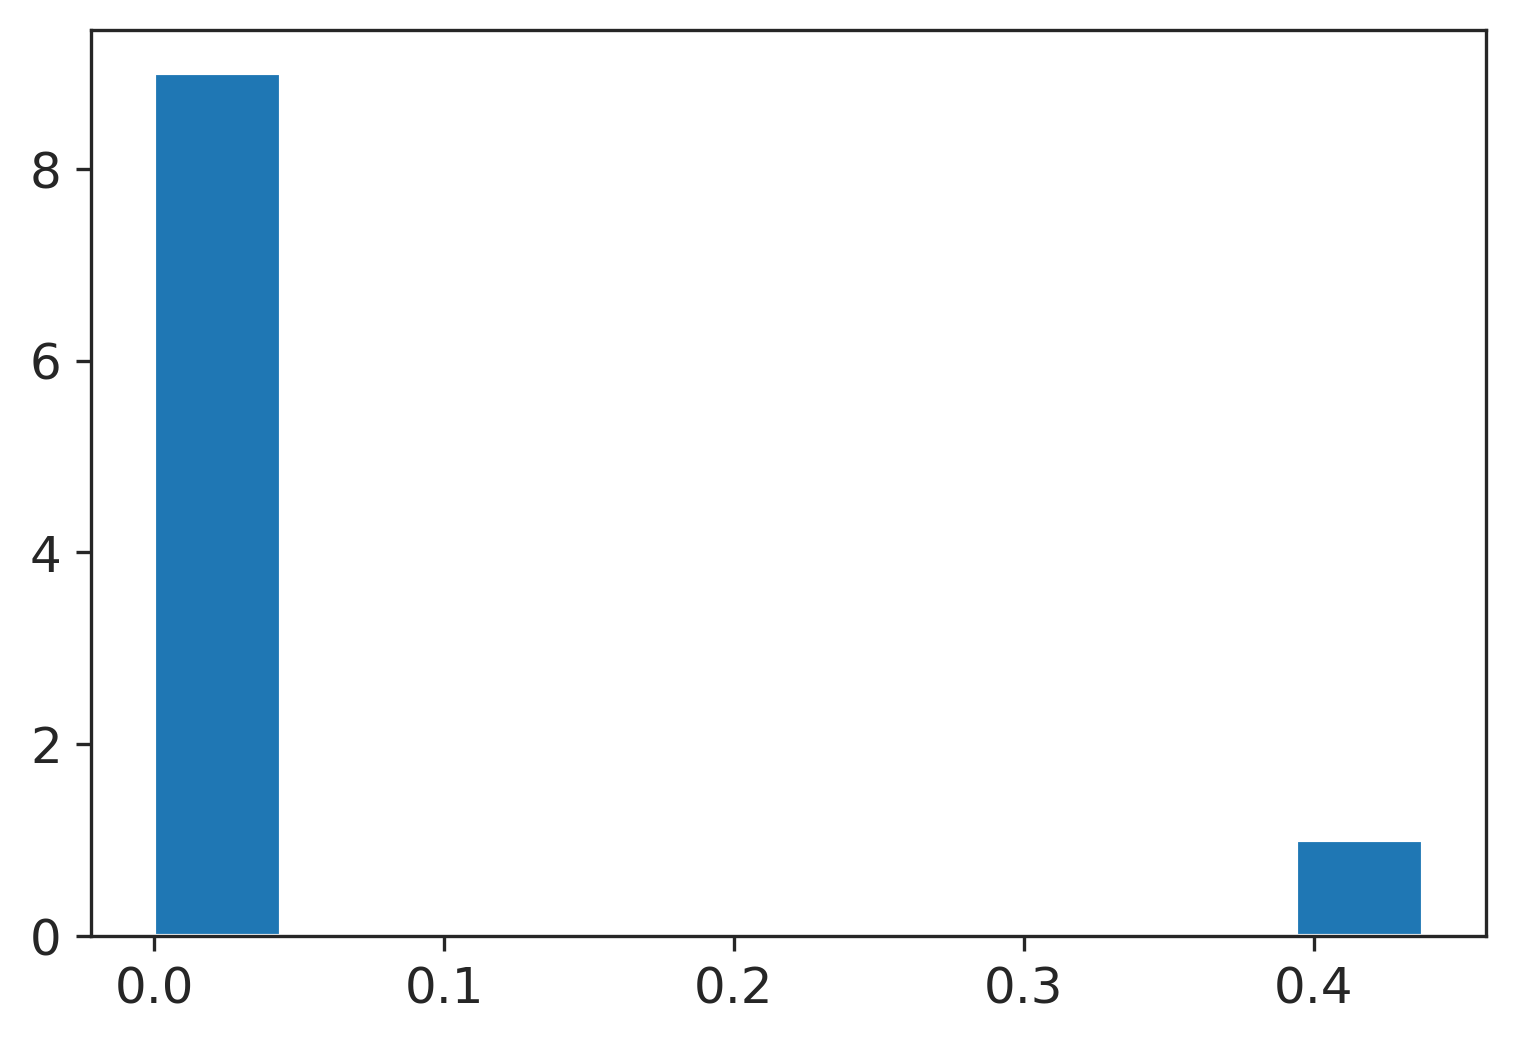

In [199]:
plt.hist(_df['MU_FREQ'][_df.index.isin(TopClones)])

In [36]:
TopClones = df_all_contig_annotations_valid_IGH.CLONE.value_counts()[:20]

In [ ]:
for clone in TopClones: 
    print(df_all_contig_annotations_valid_IGH.groupby('CLONE').sum()

In [38]:
df_all_contig_annotations_valid_IGH[df_all_contig_annotations_valid_IGH.CLONE == 2175]

,Donor,CELL,SEQUENCE_ID,SEQUENCE_INPUT,FUNCTIONAL,IN_FRAME,STOP,MUTATED_INVARIANT,INDELS,LOCUS,V_CALL,D_CALL,J_CALL,SEQUENCE_VDJ,SEQUENCE_IMGT,V_SEQ_START,V_SEQ_LENGTH,V_GERM_START_VDJ,V_GERM_LENGTH_VDJ,V_GERM_START_IMGT,V_GERM_LENGTH_IMGT,NP1_LENGTH,D_SEQ_START,D_SEQ_LENGTH,D_GERM_START,D_GERM_LENGTH,NP2_LENGTH,J_SEQ_START,J_SEQ_LENGTH,J_GERM_START,J_GERM_LENGTH,JUNCTION,JUNCTION_LENGTH,GERMLINE_IMGT,V_SCORE,V_IDENTITY,V_EVALUE,V_CIGAR,D_SCORE,D_IDENTITY,D_EVALUE,D_CIGAR,J_SCORE,J_IDENTITY,J_EVALUE,J_CIGAR,FWR1_IMGT,FWR2_IMGT,FWR3_IMGT,FWR4_IMGT,CDR1_IMGT,CDR2_IMGT,CDR3_IMGT,CLONE,GERMLINE_IMGT_D_MASK,GERMLINE_V_CALL,GERMLINE_D_CALL,GERMLINE_J_CALL,MU_COUNT_SEQ_R,MU_COUNT_SEQ_S,MU_FREQ_SEQ_R,MU_FREQ_SEQ_S,MU_FREQ,MU_COUNT
1097,Donor_2,D2_5_10_SplitSort_Dilution_Combined_A19,bracer_D2_5_10_SplitSort_Dilution_Combined_A19...,TCTCCAAGGAGTCTGTGCCGAAGTGCAGCTGGTGCAGTCCGGAGCA...,True,True,False,NaN,False,IGH,IGHV5-10-1*03,IGHD2-2*02,IGHJ5*02,GAAGTGCAGCTGGTGCAGTCCGGAGCAGAGGTGAAAAAGCCCGGGG...,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,20,294,1,294,1,318,3,317.0,25.0,5.0,25.0,6.0,348,51,1,51,TGTGCGAGACGGTATTGTAGTAGTACCAGCTGCTATAGGCGGGACA...,63,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,459.0,1.0000,3.800000e-131,19S294=,48.8,1.0,8.840000e-10,316S4N25=,98.7,1.0,1.450000e-24,347S51=,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,ATCAGCTGGGTGCGCCAGATGCCCGGGAAAGGCCTGGAGTGGATGG...,AACTACAGCCCGTCCTTCCAA...GGCCACGTCACCATCTCAGCTG...,TGGGGCCAGGGAACCCTGGTCACCGTCTCCTCAG,GGATACAGCTTT............ACCAGCTACTGG,ATTGATCCTAGT......GACTCTTATACC,GCGAGACGGTATTGTAGTAGTACCAGCTGCTATAGGCGGGACAACT...,2175,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,IGHV5-10-1*03,IGHD2-2*02,IGHJ5*02,0,0,0.000000,0.0,0.000000,0
1099,Donor_2,D2_5_10_SplitSort_Dilution_Combined_A23,bracer_D2_5_10_SplitSort_Dilution_Combined_A23...,AGGGTTCCCTGGCCCCAGGGGTCAACCGCCATCCTCGCCCTCCTCC...,True,True,False,NaN,False,IGH,IGHV5-10-1*03,IGHD2-2*02,IGHJ5*02,GAAGTGCAGCTGGTGCAGTCCGGAGCAGAGGTGAAAAAGCCCGGGG...,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,73,294,1,294,1,318,3,370.0,25.0,5.0,25.0,6.0,401,51,1,51,TGTGCGAGACGGTATTGTAGTAGTACCAGCTGCTATAGGCGGGACA...,63,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,459.0,1.0000,4.230000e-131,72S294=,48.8,1.0,9.850000e-10,369S4N25=,98.7,1.0,1.610000e-24,400S51=,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,ATCAGCTGGGTGCGCCAGATGCCCGGGAAAGGCCTGGAGTGGATGG...,AACTACAGCCCGTCCTTCCAA...GGCCACGTCACCATCTCAGCTG...,TGGGGCCAGGGAACCCTGGTCACCGTCTCCTCAG,GGATACAGCTTT............ACCAGCTACTGG,ATTGATCCTAGT......GACTCTTATACC,GCGAGACGGTATTGTAGTAGTACCAGCTGCTATAGGCGGGACAACT...,2175,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,IGHV5-10-1*03,IGHD2-2*02,IGHJ5*02,0,0,0.000000,0.0,0.000000,0
1110,Donor_2,D2_5_10_SplitSort_Dilution_Combined_C16,bracer_D2_5_10_SplitSort_Dilution_Combined_C16...,TATCAACGCAGAGTACATGGGGAGTCTCCTTCACCACCCAGCTGGG...,True,True,False,NaN,False,IGH,IGHV5-10-1*03,IGHD2-2*02,IGHJ5*02,GAAGTGCAGCTGGTGCAGTCCGGAGCAGAGGTGAAAAAGCCCGGGG...,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,137,294,1,294,1,318,3,434.0,25.0,5.0,25.0,6.0,465,51,1,51,TGTGCGAGACGGTATTGTAGTAGTACCAGCTGCTATAGGCGGGACA...,63,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,459.0,1.0000,4.780000e-131,136S294=,48.8,1.0,1.110000e-09,433S4N25=,98.7,1.0,1.820000e-24,464S51=,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,ATCAGCTGGGTGCGCCAGATGCCCGGGAAAGGCCTGGAGTGGATGG...,AACTACAGCCCGTCCTTCCAA...GGCCACGTCACCATCTCAGCTG...,TGGGGCCAGGGAACCCTGGTCACCGTCTCCTCAG,GGATACAGCTTT............ACCAGCTACTGG,ATTGATCCTAGT......GACTCTTATACC,GCGAGACGGTATTGTAGTAGTACCAGCTGCTATAGGCGGGACAACT...,2175,GAAGTGCAGCTGGTGCAGTCCGGAGCA...GAGGTGAAAAAGCCCG...,IGHV5-10-1*03,IGHD2-2*02,IGHJ5*02,0,0,0.000000,0.0,0.000000,0
1112,Donor_2,D2_5_10_SplitSort_Dilution_Combined_C18,bracer_D2_5_10_SplitSort_Dilution_Combined_C18...,CGGGCATCTGGCGCACCCAGCTGGGATCTCAGGGCTTCCTTTTCTG...,True,True,False,NaN,False,IGH,IGHV5-10-1*03,IGHD2-2*02,IGHJ5*02,GAAGTGCAGCTGGTGCAGTCCGGAGCAGAGGTGAAAAAGCCCGGGG...,GAAGTGCAGCTGGTGC

In [42]:
_df = df_all_contig_annotations_valid[df_all_contig_annotations_valid.LOCUS !=
                               'IGH']

In [45]:
_df[_df.CLONE == _df.CLONE.value_counts().index[0]]

SEQUENCE_ID                                     SEQUENCE_INPUT  FUNCTIONAL  IN_FRAME   STOP  MUTATED_INVARIANT  INDELS LOCUS                   V_CALL D_CALL                      J_CALL                                       SEQUENCE_VDJ                                      SEQUENCE_IMGT  V_SEQ_START  V_SEQ_LENGTH  V_GERM_START_VDJ  V_GERM_LENGTH_VDJ  V_GERM_START_IMGT  V_GERM_LENGTH_IMGT  NP1_LENGTH  D_SEQ_START  D_SEQ_LENGTH  D_GERM_START  D_GERM_LENGTH  NP2_LENGTH  J_SEQ_START  J_SEQ_LENGTH  J_GERM_START  J_GERM_LENGTH                                 JUNCTION  JUNCTION_LENGTH                                      GERMLINE_IMGT  V_SCORE  V_IDENTITY       V_EVALUE                                            V_CIGAR  D_SCORE  D_IDENTITY  D_EVALUE D_CIGAR  J_SCORE  J_IDENTITY      J_EVALUE            J_CIGAR                                          FWR1_IMGT  \
Donor        CELL                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
Donor_0      IL6811-701-507                           bracer_IL6811-701-507_TRINITY_DN0_c0_g1_i1_L D...  GTCCTGGGCCCAGTCTGTGCTGACTCAGCCACCCTCAGCGTCTGGG...        True      True  False                NaN   False   IGL              IGLV1-44*01    NaN                    IGLJ3*02  CAGTCTGTGCTGACTCAGCCACCCTCAGCGTCTGGGACCCCCGGGC...  CAGTCTGTGCTGACTCAGCCACCCTCA...GCGTCTGGGACCCCCG...           11           292                 1                292                  1                 337           1          NaN           NaN           NaN            NaN         NaN          304            38             1             38  TGTGCAGCATGGGATGACAGCCTGAATGCTTGGGTGTTC               39  CAGTCTGTGCTGACTCAGCCACCCTCA...GCGTCTGGGACCCCCG...    453.0     0.99658  2.700000e-129                                      10S153=1X138=      NaN         NaN       NaN     NaN     73.7     1.00000  4.580000e-17            303S38=  CAGTCTGTGCTGACTCAGCCACCCTCA...GCGTCTGGGACCCCCG...   
             IL6811-706-510                           bracer_IL6811-706-510_TRINITY_DN0_c0_g1_i1_L D...  GTCCTGGGCCCAGTCTGTGCTGACTCAGCCACCCTCAGCGTCTGGG...        True      True  False                NaN   False   IGL              IGLV1-47*01    NaN                    IGLJ3*02  CAGTCTGTGCTGACTCAGCCACCCTCAGCGTCTGGGACCCCCGGGC...  CAGTCTGTGCTGACTCAGCCACCCTCA...GCGTCTGGGACCCCCG...           11           294                 1                294                  1                 339           0          NaN           NaN           NaN            NaN         NaN          305            37             2             37  TGTGCAGCATGGGATGACAGCCTGAGTGGTTGGGTGTTC               39  CAGTCTGTGCTGACTCAGCCACCCTCA...GCGTCTGGGACCCCCG...    459.0     1.00000  3.600000e-131                                            10S294=      NaN         NaN       NaN     NaN     71.8     1.00000  1.740000e-16          304S1N37=  CAGTCTGTGCTGACTCAGCCACCCTCA...GCGTCTGGGACCCCCG...   
             IL6811-711-508                           bracer_IL6811-711-508_TRINITY_DN0_c0_g1_i1_L D...  GTCCTGGGCCCAGTCTGTGCTGACTCAGCCACCCTCAGCGTCTGGG...        True      True  False                NaN   False   IGL              IGLV1-44*01    NaN